In [7]:
# =============================================================================
# COMPLETE RADIOMICS PROCESSING PIPELINE FOR MULTI-MODALITY DATASETS
# =============================================================================
# This integrated notebook cell handles the complete automation pipeline for 
# radiomics feature standardization, naming conflict resolution, dynamic mapping 
# generation, and persistent cloud storage operations.
# =============================================================================

import os
import re
from pathlib import Path
import pandas as pd

print("=" * 80)
print("🎬 STARTING COMPLETE RADIOMICS PROCESSING PIPELINE ON KAGGLE")
print("=" * 80)

# -----------------------------------------------------------------------------
# 1. GLOBAL PIPELINE CONFIGURATIONS (CONFIG)
# -----------------------------------------------------------------------------
INPUT_FILE = "../Dataset/Breast-Data/Mask1/Pre_M1.csv"
OUTPUT_DIR = "./output"
os.makedirs(OUTPUT_DIR, exist_ok=True)
TARGET_COLUMN = "Label"


# -----------------------------------------------------------------------------
# 2. FEATURE NOMENCLATURE TRANSFORMATION ALGORITHM
# -----------------------------------------------------------------------------
def clean_feature_name(col_name, target_column="Label"):
    """Standardizes radiomics feature identifiers according to scientific repository norms.

    Preprocessing Paradigm:
        1. Preserves the experimental target variable (e.g., Dose) dynamically.
        2. Isolates raw imaging modality prefixes (e.g., CT_, PET1_) and appends them as formal suffixes.
        3. Strips institutional validation or compliance standards enclosed in brackets (e.g., IBSI tags).
        4. Compresses prolonged radiomics terminology into unified abbreviations (e.g., Morph, IB, IH).
        5. Maintains diagnostic brackets while positioning the structural modality tag at the terminus.
    """
    original = str(col_name).strip()

    # Retain the exact experimental target variable structure
    protected_columns = {
        target_column,
        "INFO_PatientName",
        "INFO_NameOfRoi"
    }

    if original in protected_columns:
        return original
    
    new_name = original

    # B) Suppress institutional meta-tags and substrings enclosed within parentheses
    new_name = re.sub(r"\([^)]*\)", "", new_name)

    # C) Compress extensive radiomics ontological classes into scientific abbreviations
    new_name = re.sub(r"MORPHOLOGICAL", "Morph", new_name, flags=re.IGNORECASE)
    new_name = re.sub(r"INTENSITY-BASED", "IB", new_name, flags=re.IGNORECASE)
    new_name = re.sub(r"INTENSITY-HISTOGRAM", "IH", new_name, flags=re.IGNORECASE)

    # D) Clean whitespace discrepancies and uniformize underscores (_) within the body
    new_name = new_name.strip()
    new_name = re.sub(r"\s+", "_", new_name)
    new_name = re.sub(r"_+", "_", new_name)
    new_name = re.sub(r"^_+|_+$", "", new_name)
    new_name = re.sub(r"[^0-9a-zA-Z_]+", "_", new_name)
    new_name = re.sub(r"_+", "_", new_name)
    new_name = new_name.strip("_")
    return new_name


# -----------------------------------------------------------------------------
# 3. SPATIAL COLUMN COLLISION RESOLUTION
# -----------------------------------------------------------------------------
def make_unique_columns(columns):
    """Enforces absolute feature identification uniqueness across the dataset array.

    Resolves potential nomenclature collisions induced by feature compression processes 
    by appending serialized suffixes sequentially.
    """
    seen = {}
    unique_columns = []

    for col in columns:
        if col not in seen:
            seen[col] = 0
            unique_columns.append(col)
        else:
            seen[col] += 1
            unique_columns.append(f"{col}_{seen[col]}")

    return unique_columns


# -----------------------------------------------------------------------------
# 4. CORE PIPELINE EXECUTION ENGINE
# -----------------------------------------------------------------------------
file_path = Path(INPUT_FILE)
output_path = Path(OUTPUT_DIR)

if not file_path.exists():
    raise FileNotFoundError(f"❌ Input dataset not found at the specified path: {INPUT_FILE}")

print(f"📖 Reading dataset: {file_path.name}")

all_mappings = []

try:
    # Ingest source dataset from Kaggle environment
    df = pd.read_csv(file_path)
    empty_cols = df.columns[df.isna().all()].tolist()
    if empty_cols:
        print(f"Dropping empty columns: {empty_cols}")
        df = df.drop(columns=empty_cols)
    old_columns = df.columns.tolist()

    # Execute dynamic matrix headers transformation
    print("⏳ Running dynamic column name transformation...")
    cleaned_columns = [clean_feature_name(col, TARGET_COLUMN) for col in old_columns]

    # Resolve structural identity duplications to prevent Pandas namespace errors
    final_columns = make_unique_columns(cleaned_columns)
    df.columns = final_columns

    # Persist the standardized dataset array to the working workspace
    output_csv_name = file_path.stem + "_Cleaned.csv"
    output_csv_path = output_path / output_csv_name
    df.to_csv(output_csv_path, index=False)
    
    print(f"✅ Cleaned dataset successfully saved to:\n   {output_csv_path}")

    # Generate metadata tracking manifest for experimental provenance
    mapping_df = pd.DataFrame({
        "file_name": file_path.name,
        "old_column_name": old_columns,
        "cleaned_column_name": cleaned_columns,
        "final_column_name": final_columns
    })
    all_mappings.append(mapping_df)

except Exception as e:
    print(f"❌ Critical Error during processing: {e}")
    raise

# -----------------------------------------------------------------------------
# 5. METADATA PROVENANCE PERSISTENCE & VERIFICATION
# -----------------------------------------------------------------------------
if len(all_mappings) > 0:
    final_mapping = pd.concat(all_mappings, ignore_index=True)
    mapping_path = output_path / "column_name_mapping_all_files.csv"
    final_mapping.to_csv(mapping_path, index=False)

    print("\n" + "=" * 80)
    print("🏁 PIPELINE EXECUTION FINISHED SUCCESSFULLY!")
    print(f"🗺️ Master column mapping file saved to:\n   {mapping_path}")
    print(f"📁 Output directory is ready: {OUTPUT_DIR}")
    print("=" * 80) 
else:
    print("⚠️ Process finished with no output. Please check the input dataset structure.")

🎬 STARTING COMPLETE RADIOMICS PROCESSING PIPELINE ON KAGGLE
📖 Reading dataset: Pre_M1.csv
Dropping empty columns: ['Unnamed: 2']
⏳ Running dynamic column name transformation...
✅ Cleaned dataset successfully saved to:
   output/Pre_M1_Cleaned.csv

🏁 PIPELINE EXECUTION FINISHED SUCCESSFULLY!
🗺️ Master column mapping file saved to:
   output/column_name_mapping_all_files.csv
📁 Output directory is ready: ./output


In [8]:
!pip install imblearn
!pip install statsmodels
!pip install imbalanced-learn 

In [9]:
# =============================================================================
# SYSTEM CONFIGURATION AND REPRODUCIBLE ENVIRONMENT INITIALIZATION
# =============================================================================
# Purpose:
#   - Consolidate all external packages, statistical tools, and ML frameworks.
#   - Establish environment flags for dynamic optional dependencies.
#   - Enforce operational constraints to isolate global execution states.
#
# Execution Context:
#   - To maintain methodological rigor and eliminate data leakage risks, 
#     no data ingestion or matrix transformations are initiated within this cell.
# =============================================================================

import io
import sys
import warnings
from collections import Counter

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from joblib import Parallel, delayed
from scipy.stats import mannwhitneyu, spearmanr
from sklearn.base import clone
from sklearn.ensemble import (
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GroupKFold,
    StratifiedGroupKFold,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Suppress non-critical runtime warnings for production-ready reporting
warnings.filterwarnings('ignore', category=UserWarning)
# Establish global typesetting and visualization parameters for publication figures
matplotlib.rcParams['font.size'] = 11

# -----------------------------------------------------------------------------
# DYNAMIC EXTENSION VALIDATION (OPTIONAL PACKAGES)
# -----------------------------------------------------------------------------
# Inspect local runtime environment capabilities to toggle advanced functional 
# modules dynamically without breaking core model compilation pipelines.
# -----------------------------------------------------------------------------

# Hyperparameter Optimization Framework Verification (Optuna)
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False

# Gradient Boosting Framework Verification (XGBoost)
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

# Light Gradient Boosting Machine Verification (LightGBM)
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

In [10]:
df.head()

,INFO_PatientName,INFO_NameOfRoi,Morph_Volume_cm3,Morph_ApproximateVolume_cm3,Morph_voxelsCounting_vx,Morph_SurfaceArea_cm2,Morph_SurfaceToVolumeRatio_cm,Morph_Compacity,Morph_Compactness1,Morph_Compactness2,...,GLSZM_LargeZoneHighGreyLevelEmphasis,GLSZM_GreyLevelNonUniformity,GLSZM_NormalisedGreyLevelNonUniformity,GLSZM_ZoneSizeNonUniformity,GLSZM_NormalisedZoneSizeNonUniformity,GLSZM_ZonePercentage,GLSZM_GreyLevelVariance,GLSZM_ZoneSizeVariance,GLSZM_ZoneSizeEntropy,Label
0,Pre_D_P1,M1_S2_P1_R_#1,1.074417,1.090,1090,7.079835,6.589469,17.533231,0.032178,0.367899,...,5.048857e+04,10.527132,0.040803,75.976744,0.294484,0.236697,50.287257,107.050237,6.437730,1
1,Pre_D_P1,M1_S1_P1_R_#1,9.876958,9.909,9909,29.855902,3.022783,16.516654,0.034159,0.414580,...,3.217510e+06,44.866931,0.044555,244.813307,0.243112,0.101625,44.766606,9622.090625,7.083283,1
2,Pre_D_P1,M1_S3_P1_R_#1,0.187583,0.196,196,2.043052,10.891437,15.567716,0.036241,0.466662,...,5.750794e+03,3.882353,0.057093,17.794118,0.261678,0.346939,34.000865,8.868512,5.341067,1
3,Pre_D_P1,M1_S5_P1_R_#1,0.192417,0.202,202,2.246322,11.674260,17.497073,0.032245,0.369421,...,2.432606e+04,3.416667,0.071181,11.708333,0.243924,0.237624,24.484375,57.956597,5.152569,1
4,Pre_D_P1,M1_S4_P1_R_#1,0.073667,0.082,82,1.787012,24.258075,32.427989,0.017398,0.107550,...,1.516655e+03,3.000000,0.054545,29.945455,0.544463,0.670732,41.981488,1.195372,4.912734,1


In [11]:
# =============================================================================
# HYPERPARAMETER CONFIGURATION DICTIONARY & INFRASTRUCTURE MATRIX
# =============================================================================
# Purpose:
#   - Define the global configuration dictionary managing the ML pipeline.
#   - Establish strict operational parameters for feature selection filters,
#     stability pathways, nested cross-validation, and ontological categorization.
#   - Mitigate data leakage risks across data processing boundaries.
# =============================================================================


# =============================================================================
# HYPERPARAMETER CONFIGURATION DICTIONARY & INFRASTRUCTURE MATRIX
# =============================================================================

CONFIG = {

    # -------------------------------------------------------------------------
    # DATA DOMAIN PARAMETERS
    # -------------------------------------------------------------------------
    'VOLUME_COL': 'Morph_Volume_cm3_',  
    'LABEL_COL': 'Label',
    'GROUP_COL': 'INFO_PatientName',


    'PRINT_PATIENT_BREAKDOWN': False,
    # -------------------------------------------------------------------------
    # STAGE 0: UNIVARIATE SIGNIFICANCE FILTER
    # -------------------------------------------------------------------------
    'SIGNIFICANCE_ALPHA': 0.05,
    'SIGNIFICANCE_METHOD': 'fdr_bh',

    # -------------------------------------------------------------------------
    # STAGE 1: VOLUME DEPENDENCE CONTROL
    # -------------------------------------------------------------------------
    'VOLUME_CORR_THRESHOLD': 0.50,

    # -------------------------------------------------------------------------
    # STAGE 2: REDUNDANCY FILTERING
    # -------------------------------------------------------------------------
    'REDUNDANCY_CORR_THRESHOLD': 0.80,

    # -------------------------------------------------------------------------
    # STAGE 3: MULTICOLLINEARITY CONTROL (VIF)
    # -------------------------------------------------------------------------
    'VIF_THRESHOLD': 6,
    'MRMR_N_FEATURES': 16,

    # -------------------------------------------------------------------------
    # FEATURE SELECTION STRATEGY
    # -------------------------------------------------------------------------
    'FS_METHOD': 'corr_mrmr',  # Options: 'current_4stage', 'corr_mrmr', 'corr_elasticnet', 'mrmr_only'

    'USE_VOLUME_FILTER': False,

    'FS_CORR_THRESHOLD': 0.85,
    'FS_N_FEATURES': 12,

    # -------------------------------------------------------------------------
    # STAGE 4: STABILITY SELECTION
    # -------------------------------------------------------------------------
    'STABILITY_N_ITERATIONS': 500, # 2000 for final runs
    'STABILITY_SUBSAMPLE_RATIO': 0.6,
    'STABILITY_SELECTION_THRESHOLD': 0.75,

    'TARGET_PFER': 1.0,

    'ELASTICNET_L1_RATIOS': [0.6, 0.7, 0.8, 0.9, 0.95],
    'ELASTICNET_CS': [0.001, 0.01, 0.05, 0.1, 0.5],
    'ELASTICNET_COEF_THRESHOLD': 1e-3,

    # -------------------------------------------------------------------------
    # ADAPTIVE THRESHOLDING
    # -------------------------------------------------------------------------
    'STABILITY_FALLBACK_STEP': 0.05,
    'STABILITY_FALLBACK_MIN_THRESHOLD': 0.55,
    'STABILITY_FALLBACK_MIN_FEATURES': 2,

    # -------------------------------------------------------------------------
    # NESTED CROSS-VALIDATION
    # -------------------------------------------------------------------------
    'N_OUTER_FOLDS': 5,
    'N_INNER_FOLDS': 3,
    'N_OPTUNA_TRIALS': 20,
    'RANDOM_STATE': 100,

    # -------------------------------------------------------------------------
    # GROUPED CV (PATIENT-AWARE)
    # -------------------------------------------------------------------------
    'GKFOLD_N_SPLITS': 5,
    'GKFOLD_N_BOOTSTRAP': 2000,
    'GKFOLD_BOOTSTRAP_CI': 0.95,

    # -------------------------------------------------------------------------
    # LOGGING
    # -------------------------------------------------------------------------
    'VERBOSE_FS': False,

    # -------------------------------------------------------------------------
    # FEATURE TAXONOMY (RADIONICS IBSI GROUPING)
    # -------------------------------------------------------------------------
    'CATEGORY_PATTERNS': {
        'MORPHOLOGY': [
            'shape', 'mesh', 'volume', 'surface', 'diameter',
            'sphericity', 'compactness', 'elongation', 'flatness'
        ],
        'INTENSITY': [
            'firstorder', 'histogram'
        ],
        'TEXTURE': [
            'glcm', 'glrlm', 'glszm', 'gldm', 'ngtdm'
        ],
    },
}


# -----------------------------------------------------------------------------
# PIPELINE VERIFICATION AND HARDWARE ENVIRONMENT LOGGING
# -----------------------------------------------------------------------------
print("█" * 80)
print("   ✅ CELL 4: CONFIGURATION LOADED — NO LEAKAGE PIPELINE")
print("█" * 80)
print(f"\n   Libraries: numpy, pandas, scipy, sklearn, matplotlib")
print(f"   Optional:  Optuna={HAS_OPTUNA} | XGBoost={HAS_XGB} | LightGBM={HAS_LGBM}")
print(f"   Random State: {CONFIG['RANDOM_STATE']}")
print(
    f"   Evaluation: Nested CV | "
    f"Outer={CONFIG['N_OUTER_FOLDS']} | Inner={CONFIG['N_INNER_FOLDS']} | "
    f"Patient-aware=True"
)
print(f"   Verbose FS: {CONFIG['VERBOSE_FS']}")

████████████████████████████████████████████████████████████████████████████████
   ✅ CELL 4: CONFIGURATION LOADED — NO LEAKAGE PIPELINE
████████████████████████████████████████████████████████████████████████████████

   Libraries: numpy, pandas, scipy, sklearn, matplotlib
   Optional:  Optuna=True | XGBoost=True | LightGBM=True
   Random State: 100
   Evaluation: Nested CV | Outer=5 | Inner=3 | Patient-aware=True
   Verbose FS: False


In [12]:
# Verify volume column after Cell 1 column cleaning

volume_candidates = [
    c for c in df.columns
    if "Volume" in c and "ApproximateVolume" not in c
]

print("Volume candidates:", volume_candidates)

if CONFIG["VOLUME_COL"] not in df.columns:
    # if len(volume_candidates) == 1:
    CONFIG["VOLUME_COL"] = volume_candidates[0]
        # print(f"CONFIG['VOLUME_COL'] updated to: {CONFIG['VOLUME_COL']}")
    # else:
    #     raise ValueError(
    #         f"Could not uniquely identify volume column. Candidates: {volume_candidates}"
    #     )
else:
    print(f"CONFIG['VOLUME_COL'] verified: {CONFIG['VOLUME_COL']}")

volume_col = CONFIG["VOLUME_COL"]
volume_col

Volume candidates: ['Morph_Volume_cm3', 'Morph_SurfaceToVolumeRatio_cm']


'Morph_Volume_cm3'

In [13]:
CONFIG['VOLUME_COL'] = volume_col
assert CONFIG['LABEL_COL'] in df.columns
assert CONFIG['GROUP_COL'] in df.columns
assert CONFIG['VOLUME_COL'] in df.columns

In [14]:
# =============================================================================
# DATA INGESTION, METADATA ISOLATION, AND PREPROCESSING FILTERS
# =============================================================================
# Purpose:
#   - Ingest the standardized multi-modality radiomics dataset from storage.
#   - Isolate diagnostic features from clinical metadata and non-predictive keys.
#   - Robustly handle missing values (NaN/Inf) via median imputation.
#   - Prune invariant (constant) features to streamline computational overhead.
# =============================================================================

print("█" * 80)
print("  📂 DATA LOADING: CLEANED Pre_M1 DATASET")
print("█" * 80)

import numpy as np
import pandas as pd

# --- Load Standardized Cohort ------------------------------------------------
df = pd.read_csv('output/Pre_M1_Cleaned.csv')

# --- Metadata and Exclusion Filter Design ------------------------------------
# Identify structural identification keys, batch definitions, and administrative 
# strings to protect the underlying training architecture from covariate leakage.
non_feature_cols = [
    CONFIG['LABEL_COL'],
    CONFIG['GROUP_COL'],
    'INFO_NameOfRoi',
    'Unnamed: 0'
]

# --- Feature Vector Extraction -----------------------------------------------
# Isolate dynamic computational features by matching criteria against the exclusion list
# and enforcing strict numeric datatype evaluation.
feature_cols = df.select_dtypes(include=[np.number]).columns
feature_cols = [c for c in feature_cols if c not in non_feature_cols]

X_raw = df[feature_cols].values.astype(np.float64)
y = df[CONFIG['LABEL_COL']].values.astype(int)
feature_names_raw = list(feature_cols)

# --- Group-Aware Covariate Identification ------------------------------------
# Extract cohort names or subject identifiers to map patient-specific structures.
if CONFIG['GROUP_COL'] not in df.columns:
    raise ValueError(
        f"Required group column '{CONFIG['GROUP_COL']}' not found. "
        "Patient-aware CV is required to avoid patient-level leakage."
    )

groups = df[CONFIG['GROUP_COL']].values
USE_GROUPS = True

# --- Missing and Extreme Values Mitigation (NaN / Inf) ------------------------
# Sequentially evaluate feature dimensions to substitute numerical instabilities 
# using non-parametric column median values calculated from valid entries.
nan_inf_count = 0
bad_mask = np.isnan(X_raw) | np.isinf(X_raw)
nan_inf_count = int(bad_mask.sum())

if nan_inf_count > 0:
    print(
        f"\n  ⚠️ Found {nan_inf_count} NaN/Inf values. "
        "Do not impute here. Imputation must be performed inside each CV fold."
    )
else:
    print("\n  ✅ No NaN/Inf values detected")

# --- Zero-Variance Feature Pruning -------------------------------------------
# Filter out redundant zero-variance columns by setting a strict minimum 
# variance floor threshold to ensure mathematical optimization stability.
X = X_raw.copy()
feature_names = feature_names_raw.copy()
n_constant = int((np.std(X_raw, axis=0) <= 1e-10).sum())

print(f"      Globally constant features detected: {n_constant}")
print("      Constant-feature removal will be performed inside CV folds.")


# --- Data Profile Compilation ------------------------------------------------
data_info = {
    'n_samples':    X.shape[0],
    'n_features':   X.shape[1],
    'n_positive':   int(y.sum()),
    'n_negative':   int((1 - y).sum()),
    'n_patients':   len(np.unique(groups)) if USE_GROUPS else 'N/A',
    'n_constant_removed': int(n_constant),
}

print(f"\n  ✅ Data loaded successfully:")
print(f"      Samples:          {data_info['n_samples']}")
print(f"      Features:         {data_info['n_features']}")
print(f"      Constant detected: {n_constant} (not removed here)")
print(f"      Label=0 (benign):    {data_info['n_negative']}")
print(f"      Label=1 (malignant): {data_info['n_positive']}")
print(f"      Patients:         {data_info['n_patients']}")
print(f"      Groups available: {USE_GROUPS}")

# --- Longitudinal / Patient Cohort Integrity Verification --------------------
if USE_GROUPS and CONFIG.get('PRINT_PATIENT_BREAKDOWN', False):
    print(f"\n  📋 Patient breakdown:")
    for pat in sorted(np.unique(groups)):
        pat_y = y[groups == pat]
        n_t = (pat_y == 1).sum()
        n_n = (pat_y == 0).sum()
        flag = "⚠️ single-class" if len(np.unique(pat_y)) < 2 else ""
        print(f"      {pat:<8}: {len(pat_y):>3} samples  "
              f"(M:{n_t:>2} / B:{n_n:>2})  {flag}")
        

if USE_GROUPS:
    patient_counts = pd.Series(groups).value_counts()
    print(f"Min samples per patient: {patient_counts.min()}")
    print(f"Max samples per patient: {patient_counts.max()}")
    print(f"Median samples per patient: {patient_counts.median()}")

████████████████████████████████████████████████████████████████████████████████
  📂 DATA LOADING: CLEANED Pre_M1 DATASET
████████████████████████████████████████████████████████████████████████████████

  ✅ No NaN/Inf values detected
      Globally constant features detected: 0
      Constant-feature removal will be performed inside CV folds.

  ✅ Data loaded successfully:
      Samples:          117
      Features:         145
      Constant detected: 0 (not removed here)
      Label=0 (benign):    52
      Label=1 (malignant): 65
      Patients:         48
      Groups available: True
Min samples per patient: 1
Max samples per patient: 8
Median samples per patient: 2.0


In [15]:
# =============================================================================
# MULTI-STAGE FEATURE SELECTION ENGINE (STAGE 1 TO STAGE 4)
# =============================================================================
# Purpose:
#   - Stage 1: Eliminate morphological volume confounders using Spearman rho.
#   - Stage 2: Prune redundant features based on Pearson r and AUC rankings.
#   - Stage 3: Perform Block-wise mRMR selection separately on CT and PET blocks.
#   - Stage 4: Enforce stability selection via subsampled ElasticNet LogReg.
# =============================================================================

import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif

# -----------------------------------------------------------------------------
# STAGE 1: MORPHOLOGICAL VOLUME INDEPENDENCE FILTER
# -----------------------------------------------------------------------------
def stage1_volume_independence(X_train, feat_names, volume_col, threshold,
                               category_patterns, all_feature_names_original,
                               X_train_original):
    print("\n" + "═" * 75)
    print("  📐 Stage 1: Volume Independence Filter")
    print(f"     Threshold: |ρ_Spearman| > {threshold}")
    print("═" * 75)

    n_input = len(feat_names)

    # Morphology flag (for reporting only, NOT for automatic removal)
    morph_keywords = category_patterns.get('MORPHOLOGY', [])
    morph_flag = {}
    for fn in feat_names:
        fn_lower = fn.lower()
        is_morph = any(kw.lower() in fn_lower for kw in morph_keywords)
        is_morph = is_morph or any(tag in fn_lower
                                    for tag in ['morphological', '_morph_', '_shape_'])
        morph_flag[fn] = is_morph

    # Find volume vector
    vol_vector = None
    vol_source = "NOT FOUND"

    # Try 1: from original feature matrix
    if all_feature_names_original is not None and volume_col in all_feature_names_original:
        vol_idx = all_feature_names_original.index(volume_col)
        vol_vector = X_train_original[:, vol_idx]
        vol_source = volume_col

    # Try 2: fallback search in original
    if vol_vector is None and all_feature_names_original is not None:
        for i_col, fn_col in enumerate(all_feature_names_original):
            fn_lower = fn_col.lower()
            if (
                ('volume' in fn_lower or 'meshvolume' in fn_lower)
                and 'approximate' not in fn_lower
            ):
                vol_vector = X_train_original[:, i_col]
                vol_source = fn_col
                break

    # Try 3: from current features
    if vol_vector is None:
        for i_col, fn_col in enumerate(feat_names):
            fn_lower = fn_col.lower()
            if (
                ('volume' in fn_lower or 'meshvolume' in fn_lower)
                and 'approximate' not in fn_lower
            ):              
                vol_vector = X_train[:, i_col]
                vol_source = fn_col
                break

    print(f"   📦 Volume column: {vol_source}")

    vol_corr_mask = np.zeros(n_input, dtype=bool)
    vol_details = {}

    if vol_vector is not None:
        print(f"\n  {'Feature':<55} {'|ρ|':>6}  {'Status':<10}  {'Morph?':>6}")
        print("  " + "─" * 85)

        for j in range(n_input):
            fn = feat_names[j]
            try:
                rho, _ = spearmanr(X_train[:, j], vol_vector)
                abs_rho = abs(rho) if np.isfinite(rho) else 0.0
            except Exception:
                abs_rho = 0.0

            vol_details[fn] = abs_rho

            if abs_rho > threshold:
                vol_corr_mask[j] = True
                print(f"     ❌ {fn[:53]:53s} {abs_rho:6.3f}  REMOVED   "
                      f"{str(morph_flag[fn]):>6}")
            elif abs_rho > threshold * 0.7:
                print(f"     ⚠️ {fn[:53]:53s} {abs_rho:6.3f}  kept      "
                      f"{str(morph_flag[fn]):>6}")
    else:
        print("  ⚠️ Volume column NOT FOUND — skipping this stage")

    keep_idx = np.where(~vol_corr_mask)[0]

    print(f"\n  📊 Summary: {n_input} → {len(keep_idx)} "
          f"(removed {int(vol_corr_mask.sum())} volume-dependent)")

    info = {
        'n_input': n_input,
        'n_output': len(keep_idx),
        'n_vol_dep_removed': int(vol_corr_mask.sum()),
        'vol_corr_details': vol_details,
        'removed_features': [feat_names[i] for i in np.where(vol_corr_mask)[0]],
        'kept_features': [feat_names[i] for i in keep_idx],
        'morph_flag': morph_flag,
    }
    return keep_idx, info


# -----------------------------------------------------------------------------
# STAGE 2: REDUNDANCY REDUCTION (PEARSON PAIR-WISE CLUSTERING)
# -----------------------------------------------------------------------------
def stage2_redundancy_reduction(X_train, y_train, feat_names, threshold=0.90):
    print("\n" + "═" * 75)
    print("  🔗 Stage 2: Redundancy Reduction (Pearson |r| clustering)")
    print(f"     Threshold: |r| > {threshold}")
    print("═" * 75)

    n_input = len(feat_names)
    corr_matrix = np.nan_to_num(
        np.corrcoef(X_train, rowvar=False),
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )
    auc_scores = np.zeros(n_input)
    for j in range(n_input):
        try:
            if np.std(X_train[:, j]) < 1e-12:
                auc_scores[j] = 0.5
            else:
                auc = roc_auc_score(y_train, X_train[:, j])
                auc_scores[j] = max(auc, 1 - auc)
        except Exception:
            auc_scores[j] = 0.5

    remaining = set(range(n_input))
    selected_idx = []
    removal_reasons = {}

    for idx in np.argsort(-auc_scores):
        if idx not in remaining:
            continue
        selected_idx.append(idx)
        remaining.discard(idx)

        to_remove = set()
        for other in remaining:
            if abs(corr_matrix[idx, other]) > threshold:
                to_remove.add(other)
                removal_reasons[other] = (idx, corr_matrix[idx, other])
        remaining -= to_remove

    selected_idx = sorted(selected_idx)
    removed_features = [i for i in range(n_input) if i not in selected_idx]

    print(f"\n  📋 All features ranked by AUC:")
    print(f"  {'#':<4} {'Feature':<55} {'AUC':<8} {'Status':<10}")
    print("  " + "─" * 80)
    for rank, idx in enumerate(np.argsort(-auc_scores), 1):
        status = "✅ KEPT" if idx in selected_idx else "❌ REMOVED"
        print(f"  {rank:<4} {feat_names[idx][:53]:<55} "
              f"{auc_scores[idx]:.4f}  {status}")

    if removed_features:
        print(f"\n  ❌ REMOVED {len(removed_features)} features (beaten by correlated feature):")
        print(f"  {'#':<4} {'Removed':<42} {'AUC':<8} {'Beaten By':<32} {'|r|':<8}")
        print("  " + "─" * 95)
        for rank, idx in enumerate(removed_features, 1):
            if idx in removal_reasons:
                w_idx, corr_val = removal_reasons[idx]
                print(f"  {rank:<4} {feat_names[idx][:40]:<42} "
                      f"{auc_scores[idx]:.4f}  "
                      f"{feat_names[w_idx][:30]:<32} {abs(corr_val):.4f}")

    print(f"\n  ✅ KEPT {len(selected_idx)} features:")
    for rank, idx in enumerate(selected_idx, 1):
        print(f"     {rank}. {feat_names[idx][:55]} (AUC: {auc_scores[idx]:.4f})")

    print(f"\n  📊 Summary: {n_input} → {len(selected_idx)}")

    info = {
        'n_input': n_input,
        'n_output': len(selected_idx),
        'threshold': threshold,
        'removed_features': [(feat_names[i], float(auc_scores[i]),
                              feat_names[removal_reasons[i][0]] if i in removal_reasons else "N/A",
                              float(abs(removal_reasons[i][1])) if i in removal_reasons else 0)
                             for i in removed_features],
        'kept_features': [feat_names[i] for i in selected_idx],
        'auc_scores': dict(zip(feat_names, auc_scores.tolist())),
    }
    return np.array(selected_idx), auc_scores, info


# -----------------------------------------------------------------------------
# STAGE 3: BLOCK-WISE mRMR (MODALITY SPECIFIC DISCRIMINATION)
# -----------------------------------------------------------------------------


def stage3_mrmr_selection_blockwise(X_train, y_train, feat_names, n_features=14):
    print("\n" + "═" * 75)
    print("  🧠 Stage 3: mRMR Selection (Single Modality)")
    print("═" * 75)

    if len(np.unique(y_train)) < 2:
        raise ValueError("Stage 3 mRMR requires at least two classes in y_train.")

    n_features = min(n_features, X_train.shape[1])
    class_counts = np.bincount(y_train.astype(int))
    min_class_count = class_counts[class_counts > 0].min()
    safe_neighbors = max(1, min(3, min_class_count - 1))

    relevance = mutual_info_classif(
        X_train,
        y_train,
        random_state=42,
        n_neighbors=safe_neighbors
    )

    corr_mat = np.nan_to_num(np.corrcoef(X_train, rowvar=False))

    selected = []
    remaining = list(range(X_train.shape[1]))

    for k in range(n_features):
        best_score = -np.inf
        best_idx = None

        for idx in remaining:
            rel = relevance[idx]
            if len(selected) == 0:
                red = 0
            else:
                red = np.mean([abs(corr_mat[idx, s]) for s in selected])

            score = rel - red

            if score > best_score:
                best_score = score
                best_idx = idx

        selected.append(best_idx)
        remaining.remove(best_idx)

        print(f"   {k+1}. {feat_names[best_idx]:<40} score={best_score:.4f}")

    return selected, relevance, {"kept_features": [feat_names[i] for i in selected]}


# -----------------------------------------------------------------------------
# STAGE 4: RESAMPLED STABILITY SELECTION (ELASTIC-NET LOGISTIC REGRESSION)
# -----------------------------------------------------------------------------
def stage4_stability_selection(X_train, y_train, feat_names,
                               n_iterations=300, subsample_ratio=0.5,
                               sel_threshold=0.75, l1_ratios=None,
                               Cs=None, random_state=42,
                               coef_threshold=1e-3,
                               fallback_step=0.05,       
                               fallback_min_threshold=0.40,  
                               fallback_min_features=3):     

    print("\n" + "═" * 75)
    print("  🎯 Stage 4: Stability Selection (ElasticNet LogReg)")
    print(f"     Iterations: {n_iterations} | Subsample: {subsample_ratio}")
    print(f"     Selection threshold: {sel_threshold}")
    print(f"     Coefficient threshold: {coef_threshold}")
    print(f"     Fallback: step={fallback_step}, "
          f"min_thresh={fallback_min_threshold}, "
          f"min_features={fallback_min_features}")
    print("═" * 75)

    if len(np.unique(y_train)) < 2:
        raise ValueError("Stage 4 stability selection requires at least two classes in y_train.")

    if l1_ratios is None:
        l1_ratios = [0.8, 0.9, 0.95, 1.0]
    if Cs is None:
        Cs = [0.005, 0.01, 0.05, 0.1]

    n_features = len(feat_names)
    n_samples = X_train.shape[0]
    n_sub = max(int(n_samples * subsample_ratio), 10)

    # Scale once
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    selection_count = np.zeros(n_features)
    coef_accumulator = np.zeros(n_features)
    rng = np.random.RandomState(random_state)

    successful = 0
    failed = 0

    for it in range(n_iterations):
        # Random subsample (stratified)
        idx_0 = np.where(y_train == 0)[0]
        idx_1 = np.where(y_train == 1)[0]

        n_sub_0 = max(int(len(idx_0) * subsample_ratio), 2)
        n_sub_1 = max(int(len(idx_1) * subsample_ratio), 2)

        if len(idx_0) > 0:
            sub_0 = rng.choice(idx_0, size=min(n_sub_0, len(idx_0)), replace=False)
        else:
            sub_0 = np.array([], dtype=int)
        if len(idx_1) > 0:
            sub_1 = rng.choice(idx_1, size=min(n_sub_1, len(idx_1)), replace=False)
        else:
            sub_1 = np.array([], dtype=int)
        sub_idx = np.concatenate([sub_0, sub_1])

        X_sub = X_scaled[sub_idx]
        y_sub = y_train[sub_idx]

        # Random hyperparameters
        l1_ratio = rng.choice(l1_ratios)
        C = rng.choice(Cs)

        try:
            model = LogisticRegression(
                penalty='elasticnet', solver='saga',
                C=C, l1_ratio=l1_ratio,
                max_iter=5000,
                random_state=random_state + it,
                tol=1e-5
            )
            model.fit(X_sub, y_sub)

            coefs = np.abs(model.coef_[0])
            selected_mask = np.abs(coefs) > coef_threshold
            selection_count += selected_mask.astype(float)
            coef_accumulator += coefs
            successful += 1

        except Exception:
            failed += 1

        # Progress tracking updates
        if (it + 1) % 100 == 0:
            current_freq = selection_count / max(successful, 1)
            n_passing = np.sum(current_freq >= sel_threshold)
            print(f"    ... iteration {it + 1}/{n_iterations} "
                  f"(success: {successful}, failed: {failed}, "
                  f"passing: {n_passing} features)")

    # Compute operational frequencies
    if successful > 0:
        selection_freq = selection_count / successful
        mean_coefs = coef_accumulator / successful
    else:
        selection_freq = np.zeros(n_features)
        mean_coefs = np.zeros(n_features)

    # ══════════════════════════════════════════════════════════
    # ADAPTIVE FALLBACK PROTOCOL: GRADUAL THRESHOLD DECAY
    # ══════════════════════════════════════════════════════════
    current_threshold = sel_threshold
    keep_idx = np.where(selection_freq >= current_threshold)[0]

    # Dynamically decay selection criterion if total retained features falls below safety boundaries
    if len(keep_idx) < fallback_min_features:
        print(f"\n  ⚠️  Only {len(keep_idx)} features at threshold "
              f"{current_threshold:.2f} (need ≥{fallback_min_features})")
        print(f"  🔄 Starting adaptive threshold reduction...")

        while (len(keep_idx) < fallback_min_features and
               current_threshold > fallback_min_threshold):

            current_threshold -= fallback_step
            current_threshold = round(current_threshold, 4)  # Safeguard floating-point precision bounds
            keep_idx = np.where(selection_freq >= current_threshold)[0]

            print(f"      → threshold = {current_threshold:.2f} "
                  f"→ {len(keep_idx)} features selected")

        # Absolute fallback override if minimal conditions remain unsatisfied
        if len(keep_idx) < fallback_min_features:
            print(f"\n  🚨 Still only {len(keep_idx)} features at "
                  f"minimum threshold {fallback_min_threshold:.2f}")
            print(f"  🔄 Selecting top {fallback_min_features} by frequency...")
            keep_idx = np.argsort(-selection_freq)[:fallback_min_features]
            if len(keep_idx) > 0:
                current_threshold = selection_freq[keep_idx[-1]]
            else:
                current_threshold = fallback_min_threshold
            print(f"      → Effective threshold: {current_threshold:.3f}")

        if current_threshold < sel_threshold:
            print(f"\n  📌 Final threshold: {current_threshold:.2f} "
                  f"(original: {sel_threshold:.2f})")

    # --- Verbose Output Generation -------------------------------------------
    print(f"\n  📋 Feature selection frequencies "
          f"(threshold used: {current_threshold:.2f}):")
    print(f"  {'#':<4} {'Feature':<55} {'Freq':<8} "
          f"{'MeanCoef':<10} {'Status':<10}")
    print("  " + "─" * 90)

    for rank, idx in enumerate(np.argsort(-selection_freq), 1):
        status = "✅ KEPT" if selection_freq[idx] >= current_threshold else "❌"
        print(f"  {rank:<4} {feat_names[idx][:53]:<55} "
              f"{selection_freq[idx]:.3f}  {mean_coefs[idx]:.6f}  {status}")

    print(f"\n  📊 Summary: {n_features} → {len(keep_idx)} "
          f"(removed {n_features - len(keep_idx)})")
    print(f"     Successful iterations: {successful}/{n_iterations}")
    if current_threshold < sel_threshold:
        print(f"     ⚠️  Threshold was reduced: "
              f"{sel_threshold:.2f} → {current_threshold:.2f}")

    info = {
        'n_input': n_features,
        'n_output': len(keep_idx),
        'n_iterations_success': successful,
        'n_iterations_failed': failed,
        'original_threshold': sel_threshold,
        'final_threshold': current_threshold,
        'threshold_was_reduced': current_threshold < sel_threshold,
        'selection_frequencies': dict(zip(feat_names, selection_freq.tolist())),
        'mean_coefficients': dict(zip(feat_names, mean_coefs.tolist())),
        'kept_features': [feat_names[i] for i in keep_idx],
    }
    return keep_idx, selection_freq, info



# -----------------------------------------------------------------------------
# ALTERNATIVE FS: CORRELATION FILTER + ELASTICNET SELECTION
# -----------------------------------------------------------------------------
def stage_elasticnet_selection(X_train, y_train, feat_names,
                               n_features=12,
                               l1_ratio=0.8,
                               C=0.1,
                               random_state=100):
    print("\n" + "═" * 75)
    print("  🧬 Alternative FS: ElasticNet Logistic Selection")
    print(f"     Target features: {n_features}")
    print("═" * 75)

    if len(np.unique(y_train)) < 2:
        raise ValueError("ElasticNet selection requires at least two classes in y_train.")

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)

    model = LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        C=C,
        l1_ratio=l1_ratio,
        max_iter=5000,
        random_state=random_state,
        class_weight='balanced',
        tol=1e-5
    )

    model.fit(X_scaled, y_train)

    coef_abs = np.abs(model.coef_[0])

    if np.all(coef_abs == 0):
        keep_idx = np.argsort(-coef_abs)[:min(n_features, X_train.shape[1])]
    else:
        keep_idx = np.argsort(-coef_abs)[:min(n_features, X_train.shape[1])]

    keep_idx = np.array(sorted(keep_idx))

    print(f"  📊 Summary: {X_train.shape[1]} → {len(keep_idx)}")
    print("  ✅ Selected features:")
    for i, idx in enumerate(keep_idx, 1):
        print(f"     {i}. {feat_names[idx]} | coef_abs={coef_abs[idx]:.6f}")

    info = {
        "n_input": X_train.shape[1],
        "n_output": len(keep_idx),
        "kept_features": [feat_names[i] for i in keep_idx],
        "coef_abs": dict(zip(feat_names, coef_abs.tolist()))
    }

    return keep_idx, coef_abs, info

    
# -----------------------------------------------------------------------------
# PIPELINE STEP DEFINITION VERIFICATION
# -----------------------------------------------------------------------------
print(f"\n  ✅ All 4 feature selection functions defined:")
print(f"     1. stage1_volume_independence()")
print(f"     2. stage2_redundancy_reduction()")
print(f"     3. stage3_mrmr_selection_blockwise()")
print(f"     4. stage4_stability_selection()")
if 'X' in globals() and 'feature_names' in globals():
    print(f"\n  📊 Current data: X.shape = {X.shape}, features = {len(feature_names)}")


  ✅ All 4 feature selection functions defined:
     1. stage1_volume_independence()
     2. stage2_redundancy_reduction()
     3. stage3_mrmr_selection_blockwise()
     4. stage4_stability_selection()

  📊 Current data: X.shape = (117, 145), features = 145


In [16]:
# =============================================================================
# MODEL ARCHITECTURE POOL AND BASE ESTIMATOR TEMPLATES
# =============================================================================
# Purpose:
#   - Define a comprehensive dictionary of core base estimators across multiple
#     algorithmic paradigms (Linear, Kernel, Ensembles, Distance, Probabilistic).
#   - Conditionally compile advanced gradient boosting estimators based on 
#     detected environment runtime extensions.
#   - Establish standard configurations for data balance mitigation via class weights.
# =============================================================================
from sklearn.pipeline import Pipeline


print("█" * 80)
print("  🤖 CELL 3.5: MODEL DEFINITIONS")
print("█" * 80)

RANDOM_STATE = CONFIG['RANDOM_STATE']

# --- Core Model Pool Construction --------------------------------------------
NESTED_CV_MODELS = {
    # --- Parametric & Linear Estimators --------------------------------------
    'LogisticRegression': LogisticRegression(
        solver='saga',
        max_iter=5000,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        tol=1e-4,
        n_jobs=-1,
    ),
    

    # --- Structural Maximum Margin Kernels (SVM) -----------------------------

    'SVM_RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', probability=True,
                    random_state=RANDOM_STATE,
                    class_weight='balanced'))
    ]),
    'SVM_Linear': Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='linear', probability=True,
                    random_state=RANDOM_STATE,
                    class_weight='balanced'))
    ]),

    # --- Tree-Based Resampling Ensembles ------------------------------------
    'RandomForest': RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=-1,
    ),

    'GradientBoosting': GradientBoostingClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        max_depth=None,  
        max_leaf_nodes=3  
    ),

    'ExtraTrees': ExtraTreesClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE,
        class_weight='balanced',
        n_jobs=-1,
    ),
    # Note: AdaBoost classifier has been systematically excluded from this array

    # --- Non-Parametric & Instance/Distance Estimators -----------------------
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
    ]),

    # --- Generative & Probabilistic Estimators -------------------------------
    'NaiveBayes': GaussianNB(),
}

# --- Conditional Compilations (Advanced Tree Frameworks) ---------------------
# Dynamic ingestion of external execution frames if pre-validated in local space
if HAS_XGB:
    NESTED_CV_MODELS['XGBoost'] = XGBClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        use_label_encoder=False,
        eval_metric='logloss',
        verbosity=0,
        n_jobs=-1,
    )
    print("  ✅ XGBoost added to model pool")

if HAS_LGBM:
    NESTED_CV_MODELS['LightGBM'] = LGBMClassifier(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
        verbose=-1,
        n_jobs=-1,
        class_weight='balanced',
    )
    print("  ✅ LightGBM added to model pool")

# --- Pool Verification and Meta-Manifest Compilation -------------------------
print(f"\n  📦 Total models defined: {len(NESTED_CV_MODELS)}")
print(f"  {'─' * 50}")
for i, (name, model) in enumerate(NESTED_CV_MODELS.items(), 1):
    model_class = type(model).__name__
    print(f"  {i:>2}. {name:<25} → {model_class}")

print(f"\n  💡 Note: These are BASE templates.")
if HAS_OPTUNA:
    print(f"     Optuna will tune hyperparameters in the inner CV loop")
    print(f"     ({CONFIG['N_OPTUNA_TRIALS']} trials per model per outer fold)")
else:
    print(f"     ⚠️ Optuna NOT available — using default hyperparameters")

print(f"\n{'█' * 80}")

████████████████████████████████████████████████████████████████████████████████
  🤖 CELL 3.5: MODEL DEFINITIONS
████████████████████████████████████████████████████████████████████████████████
  ✅ XGBoost added to model pool
  ✅ LightGBM added to model pool

  📦 Total models defined: 10
  ──────────────────────────────────────────────────
   1. LogisticRegression        → LogisticRegression
   2. SVM_RBF                   → Pipeline
   3. SVM_Linear                → Pipeline
   4. RandomForest              → RandomForestClassifier
   5. GradientBoosting          → GradientBoostingClassifier
   6. ExtraTrees                → ExtraTreesClassifier
   7. KNN                       → Pipeline
   8. NaiveBayes                → GaussianNB
   9. XGBoost                   → XGBClassifier
  10. LightGBM                  → LGBMClassifier

  💡 Note: These are BASE templates.
     Optuna will tune hyperparameters in the inner CV loop
     (20 trials per model per outer fold)

██████████████████████

In [17]:
# =============================================================================
# REPRODUCIBLE SEQUENTIAL FEATURE SELECTION PIPELINE WRAPPER
# =============================================================================
# Purpose:
#   - Encapsulate stages 1 through 4 into a single procedural pipeline.
#   - Isolate feature space transformations locally within individual cross-validation 
#     folds to guarantee strict data separation and eliminate selection bias.
#   - Track feature coordinate tracking matrices dynamically using explicit indexing masks.
# =============================================================================

def execute_fs_pipeline_on_fold(X_train, y_train, feat_names,
                                X_orig_train, feat_names_orig, config):
    """Executes the localized multi-stage feature selection workflow within a single CV fold.

    This function sequentially filters out confounding, redundant, and unstable 
    radiomics features, ensuring that the feature space is optimized without 
    incurring cross-validation data leakage.

    Args:
        X_train (np.ndarray): Local scaled feature matrix for training within the fold.
        y_train (np.ndarray): Ground-truth class labels for target metrics mapping.
        feat_names (list of str): Current computational identifiers for the column subset.
        X_orig_train (np.ndarray): Unaltered structural reference feature training space.
        feat_names_orig (list of str): Static master nomenclature baseline array.
        config (dict): Global configurations managing algorithmic hyperparameter margins.

    Returns:
        tuple: (selected_mask, final_names) where selected_mask contains the global indices
               of the selected features, and final_names contains their string identifiers.
    """
    import numpy as np

    current_X = X_train.copy()
    current_names = list(feat_names)
    selected_mask = np.arange(X_train.shape[1])  # Dynamically track global index positions


    global_idx = np.arange(len(feat_names))

    fs_method = config.get('FS_METHOD', 'current_4stage')
    use_volume_filter = config.get('USE_VOLUME_FILTER', False)
    fs_corr_threshold = config.get('FS_CORR_THRESHOLD', config['REDUNDANCY_CORR_THRESHOLD'])
    fs_n_features = config.get('FS_N_FEATURES', config.get('MRMR_N_FEATURES', 12))

    print(f"  🔧 Feature selection method: {fs_method}")
    print(f"  🔧 Use volume filter: {use_volume_filter}")
    print(f"  🔧 Target number of features: {fs_n_features}")
    # --- Stage 1: Volume Independence Optimization ---------------------------
    try:
        keep_idx_1, info_1 = stage1_volume_independence(
            current_X, current_names,
            volume_col=config['VOLUME_COL'],
            threshold=config['VOLUME_CORR_THRESHOLD'],
            category_patterns=config['CATEGORY_PATTERNS'],
            all_feature_names_original=feat_names_orig,
            X_train_original=X_orig_train
        )
        if len(keep_idx_1) > 0:
            selected_mask = selected_mask[keep_idx_1]
            global_idx = global_idx[keep_idx_1]
            current_X = current_X[:, keep_idx_1]
            current_names = [current_names[i] for i in keep_idx_1]
            print(f"  Stage 1: {len(keep_idx_1)} features kept")
        else:
            print("  Stage 1: skipped (0 features selected, keeping all)")
    except Exception as e:
        print(f"  Stage 1 failed: {e}, skipping")

    # --- Stage 2: Pair-wise Redundancy Reduction -----------------------------
    try:
        keep_idx_2, _, info_2 = stage2_redundancy_reduction(
            current_X, y_train, current_names,
            threshold=config['REDUNDANCY_CORR_THRESHOLD']
        )
        if len(keep_idx_2) > 0:
            selected_mask = selected_mask[keep_idx_2]
            global_idx = global_idx[keep_idx_2]
            current_X = current_X[:, keep_idx_2]
            current_names = [current_names[i] for i in keep_idx_2]
            print(f"  Stage 2: {len(keep_idx_2)} features kept")
        else:
            print("  Stage 2: skipped (0 features selected, keeping all)")
    except Exception as e:
        print(f"  Stage 2 failed: {e}, skipping")

    # --- Stage 3: Modality-Specific Block-wise mRMR Selection ----------------
    try:
        # Enforce balance by dividing target feature spaces between imaging modalities
        total_mrmr = config.get('MRMR_N_FEATURES', 14)
        n_per_modality = total_mrmr // 2
        
        keep_idx_3, _, info_3 = stage3_mrmr_selection_blockwise(
            current_X, y_train, current_names,
            n_features=config.get('MRMR_N_FEATURES', 14)
        )
        if len(keep_idx_3) > 0:
            selected_mask = selected_mask[keep_idx_3]
            global_idx = global_idx[keep_idx_3]
            current_X = current_X[:, keep_idx_3]
            current_names = [current_names[i] for i in keep_idx_3]
            print(f"  Stage 3: {len(keep_idx_3)} features kept")
        else:
            print("  Stage 3: skipped (0 features selected, keeping all)")
    except Exception as e:
        print(f"  Stage 3 failed: {e}, skipping")

    # --- Stage 4: Resampled ElasticNet Stability Selection -------------------
    try:
        keep_idx_final, _, info_final = stage4_stability_selection(
            current_X, y_train, current_names,
            n_iterations=config['STABILITY_N_ITERATIONS'],
            subsample_ratio=config['STABILITY_SUBSAMPLE_RATIO'],
            sel_threshold=config['STABILITY_SELECTION_THRESHOLD'],
            l1_ratios=config['ELASTICNET_L1_RATIOS'],
            Cs=config['ELASTICNET_CS'],
            coef_threshold=config['ELASTICNET_COEF_THRESHOLD'],
            fallback_step=config.get('STABILITY_FALLBACK_STEP', 0.05),
            fallback_min_threshold=config.get('STABILITY_FALLBACK_MIN_THRESHOLD', 0.40),
            fallback_min_features=config.get('STABILITY_FALLBACK_MIN_FEATURES', 3)
        )
        if len(keep_idx_final) > 0:
            selected_mask = selected_mask[keep_idx_final]
            global_idx = global_idx[keep_idx_final]
            current_X = current_X[:, keep_idx_final]
            current_names = [current_names[i] for i in keep_idx_final]
            print(f"  Stage 4: {len(keep_idx_final)} features kept")
        else:
            print("  Stage 4: skipped (0 features selected, keeping all)")
    except Exception as e:
        print(f"  Stage 4 failed: {e}, skipping")

    # --- Consolidated Manifest Reporting -------------------------------------
    print(f"  ✅ FS Pipeline complete: {len(selected_mask)} / {X_orig_train.shape[1]} features selected")
    final_names = [feat_names_orig[i] for i in selected_mask]
    print("\n  [DEBUG] Final selected_mask:", selected_mask)
    print("  [DEBUG] current_names:", current_names)
    print("  [DEBUG] final_names from feat_names_orig:", [feat_names_orig[i] for i in selected_mask])

    return global_idx, final_names

In [18]:
pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [19]:
# =============================================================================
# NESTED CROSS-VALIDATION HYPERPARAMETER TUNING SUBSYSTEM (OPTUNA ENGINE)
# =============================================================================
# Purpose:
#   - Define conservative, publication-grade search spaces for core estimators
#     to robustly suppress over-fitting trends on low-sample radiomics cohorts.
#   - Standardize patient-aware Inner Cross-Validation loops utilizing closures.
#   - Inject localized synthetic oversampling (SMOTE) to safely mitigate class 
#     imbalances within training boundaries without structural leakage.
# =============================================================================

import optuna
import numpy as np
from collections import Counter
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from imblearn.over_sampling import SMOTE

# Enforce uniform warnings suppression across dynamic optimization trials
optuna.logging.set_verbosity(optuna.logging.WARNING)

# -----------------------------------------------------------------------------
# 1. OPTUNA CONFIGURATION BOUNDARIES AND HYPERPARAMETER SEARCH SPACES
# -----------------------------------------------------------------------------
def get_optuna_search_space(trial, model_name, random_state):
    """Generates localized parameter distributions for Optuna optimization loops.

    The continuous and discrete search margins are configured tightly to guarantee
    mathematical convergence and structural generalization on high-dimensional clinical matrices.

    Args:
        trial (optuna.trial.Trial): Active operational optimization trial instance.
        model_name (str): Unique identifier match key for the targeted estimator paradigm.
        random_state (int): Global seed managing reproducible random distributions.

    Returns:
        BaseEstimator: An uncompiled Scikit-Learn estimator instantiated with sampled parameters.
    """
    if model_name == 'LogisticRegression':
        C = trial.suggest_float('C', 1e-4, 10.0, log=True)
        l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
        return LogisticRegression(
            C=C, l1_ratio=l1_ratio, penalty='elasticnet',
            solver='saga', max_iter=3000, random_state=random_state
        )

    elif model_name == 'SVM_RBF':
        C = trial.suggest_float(
            'C',
            1e-3,
            100,
            log=True
        )        
        gamma = trial.suggest_float(
            'gamma',
            1e-4,
            1,
            log=True
        )
        return SVC(
            C=C, kernel='rbf', gamma=gamma,
            probability=True, random_state=random_state
        )

    elif model_name == 'SVM_Linear':
        C = trial.suggest_float('C', 1e-3, 50.0, log=True)
        return SVC(
            C=C, kernel='linear',
            probability=True, random_state=random_state
        )

    elif model_name == 'RandomForest':
        n_estimators = trial.suggest_int('n_estimators', 50, 200, step=50)
        max_depth = trial.suggest_int(
            'max_depth',
            2,
            8
        )
        min_samples_leaf = trial.suggest_int(
            'min_samples_leaf',
            1,
            10
        )
        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        return RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            min_samples_leaf=min_samples_leaf, max_features=max_features,
            random_state=random_state, n_jobs=-1
        )

    elif model_name == 'GradientBoosting':
        n_estimators = trial.suggest_int('n_estimators', 25, 100, step=25)
        max_depth = trial.suggest_int('max_depth', 1, 3)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
        subsample = trial.suggest_float('subsample', 0.7, 1.0)
        return GradientBoostingClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            random_state=random_state
        )

    elif model_name == 'ExtraTrees':
        n_estimators = trial.suggest_int('n_estimators', 50, 500, step=50)
        max_depth = trial.suggest_int('max_depth', 2, 10)
        min_samples_leaf = trial.suggest_int('min_samples_leaf', 2, 20)
        max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
        return ExtraTreesClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            min_samples_leaf=min_samples_leaf, max_features=max_features,
            random_state=random_state, n_jobs=-1
        )

    elif model_name == 'KNN':
        n_neighbors = trial.suggest_int(
            'n_neighbors',
            3,
            15
        )        
        weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
        metric = trial.suggest_categorical(
        'metric',
            ['euclidean', 'manhattan']
        )

        return KNeighborsClassifier(
            n_neighbors=n_neighbors,
            weights=weights,
            metric=metric
        )

    elif model_name == 'NaiveBayes':
        var_smoothing = trial.suggest_float('var_smoothing', 1e-12, 1e-6, log=True)
        return GaussianNB(var_smoothing=var_smoothing)

    elif model_name == 'XGBoost' and HAS_XGB:
        n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
        max_depth = trial.suggest_int('max_depth', 2, 8)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        subsample = trial.suggest_float('subsample', 0.6, 1.0)
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
        reg_alpha = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True)
        reg_lambda = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
        return XGBClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha, reg_lambda=reg_lambda,
            random_state=random_state, use_label_encoder=False,
            eval_metric='logloss', verbosity=0
        )

    elif model_name == 'LightGBM' and HAS_LGBM:
        n_estimators = trial.suggest_int('n_estimators', 50, 300, step=50)
        max_depth = trial.suggest_int('max_depth', 2, 8)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        num_leaves = trial.suggest_int('num_leaves', 8, 64)
        subsample = trial.suggest_float('subsample', 0.6, 1.0)
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
        reg_alpha = trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True)
        reg_lambda = trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True)
        return LGBMClassifier(
            n_estimators=n_estimators, max_depth=max_depth,
            learning_rate=learning_rate, num_leaves=num_leaves,
            subsample=subsample, colsample_bytree=colsample_bytree,
            reg_alpha=reg_alpha, reg_lambda=reg_lambda,
            random_state=random_state, verbose=-1
        )

    else:
        # Static Fallback Model Assignment
        return clone(NESTED_CV_MODELS[model_name])


# -----------------------------------------------------------------------------
# 2. LOCALIZED RESAMPLING FRAMEWORK (SMOTE PRESERVATION)
# -----------------------------------------------------------------------------
def apply_smote_if_possible(X, y, random_state=42):
    """Safely executes SMOTE balancing if valid structural prerequisites are met.

    Protects the pipeline compilation from failure loops in extremely small cohorts 
    by adaptively down-scaling nearest neighbor checks based on the minority class count.
    """
    classes, counts = np.unique(y, return_counts=True)

    if len(classes) < 2:
        return X, y

    minority_count = np.min(counts)

    if minority_count < 2:
        return X, y

    # Dynamically optimize k_neighbors margin relative to minority sample availability
    k_neighbors = min(5, minority_count - 1)

    try:
        smote = SMOTE(random_state=random_state, k_neighbors=k_neighbors)
        return smote.fit_resample(X, y)
    except Exception:
        return X, y


# -----------------------------------------------------------------------------
# 3. CLOSED INNER-LOOP OPTIMIZATION OBJECTIVE FUNCTION
# -----------------------------------------------------------------------------
def make_optuna_objective(model_name, X_inner, y_inner, groups_inner,
                          n_inner_folds, random_state, use_smote=False):
    """Constructs a localized cross-validation tracking instance for Optuna tuning routines.

    Enforces strict patient-level grouping segregation dynamically when tracking matrix structures 
    to preserve mathematical generalization integrity and counter diagnostic target leakage.
    """
    def objective(trial):
        clf = get_optuna_search_space(trial, model_name, random_state)

        n_unique = len(np.unique(groups_inner)) if groups_inner is not None else 0
        actual_inner_folds = min(n_inner_folds, n_unique) if n_unique > 1 else n_inner_folds

        # Patient-Aware Configuration Routing Strategy
        if groups_inner is not None and n_unique > 1 and actual_inner_folds >= 2:
            inner_cv = StratifiedGroupKFold(
                n_splits=actual_inner_folds,
                shuffle=True,
                random_state=random_state
            )
            splits = list(inner_cv.split(X_inner, y_inner, groups_inner))
        else:
            inner_cv = StratifiedKFold(
                n_splits=n_inner_folds,
                shuffle=True,
                random_state=random_state
            )
            splits = list(inner_cv.split(X_inner, y_inner))

        auc_scores = []

        # Functional Internal Cross-Validation Optimization Loop
        for tr_idx, val_idx in splits:
            X_tr, X_val = X_inner[tr_idx], X_inner[val_idx]
            y_tr, y_val = y_inner[tr_idx], y_inner[val_idx]

            # Enforce strict internal operational transformation sequence
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_val = sc.transform(X_val)

            if use_smote:
                X_tr, y_tr = apply_smote_if_possible(
                    X_tr, y_tr, random_state=random_state
                )

            try:
                clf_clone = clone(clf)
                clf_clone.fit(X_tr, y_tr)

                # Route classification matrix probabilities dynamically based on object attributes
                if hasattr(clf_clone, "predict_proba"):
                    y_prob_val = clf_clone.predict_proba(X_val)[:, 1]
                elif hasattr(clf_clone, "decision_function"):
                    y_prob_val = clf_clone.decision_function(X_val)
                else:
                    y_prob_val = clf_clone.predict(X_val)
                if len(np.unique(y_val)) < 2:
                    continue
                auc = roc_auc_score(y_val, y_prob_val)

            except Exception:
                auc = 0.5  # Strategic floor fallback for unconverged models

            auc_scores.append(auc)

        mean_auc = np.median(auc_scores)
        complexity_penalty = 0.001 * X_inner.shape[1]
        return mean_auc - complexity_penalty

    return objective

In [20]:
# =============================================================================
# INTEGRATED NESTED CROSS-VALIDATION MATRIX, OPTUNA TUNING, AND I/O SUBSYSTEM
# =============================================================================
# Purpose:
#   - Execute an un-leaked Nested Cross-Validation (Stratified or Group aware).
#   - Conduct inner-loop hyperparameter exploration with Optuna TPE samplers.
#   - Apply training-confined synthetic oversampling (SMOTE) to prevent leakages.
#   - Compile comprehensive statistics (mean, std, pooled) for multi-metric profiles.
#   - Persist tabular exports, serialized binary assets, and operational meta-logs.
# =============================================================================

import os
import json
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, average_precision_score, confusion_matrix
)

# Operational Prerequisite Assumption:
# Global baseline frames (CONFIG, NESTED_CV_MODELS, X, y, feature_names, X_raw, 
# feature_names_raw, execute_fs_pipeline_on_fold, make_optuna_objective, 
# get_optuna_search_space, and optionally 'groups') must be initialized in runtime.

# =============================================================================
# ANALYTICAL PIPELINE UTILITY HIGHER-ORDER FUNCTIONS
# =============================================================================

def apply_smote_if_possible(X, y, random_state=100):
    """Safely executes SMOTE balancing if valid structural prerequisites are met."""
    class_counts = Counter(y)
    minority_count = min(class_counts.values())

    if minority_count < 2:
        return X, y

    k_neighbors = min(5, minority_count - 1)
    smote = SMOTE(random_state=random_state, k_neighbors=k_neighbors)
    X_res, y_res = smote.fit_resample(X, y)
    return X_res, y_res


def compute_specificity(y_true, y_pred):
    """Computes binary True Negative Rate (Specificity) via confusion matrix analysis."""
    try:
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        if cm.shape != (2, 2):
            return np.nan
        tn, fp, fn, tp = cm.ravel()
        return tn / (tn + fp) if (tn + fp) > 0 else np.nan
    except Exception:
        return np.nan


def to_serializable(obj):
    """Recursively converts NumPy numeric primitives into standard JSON serializable objects."""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, (np.integer, )):
        return int(obj)
    if isinstance(obj, (np.floating, )):
        return float(obj)
    if isinstance(obj, dict):
        return {k: to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_serializable(v) for v in obj]
    return obj


def build_oof_predictions_dataframe(nested_cv_results):
    """Assembles an unrolled out-of-fold predictions data matrix for tabular modeling."""
    rows = []
    for model_name, results in nested_cv_results.items():
        n = len(results['y_true'])
        for i in range(n):
            rows.append({
                'Model': model_name,
                'y_true': results['y_true'][i],
                'y_prob': results['y_prob'][i],
                'y_pred': results['y_pred'][i]
            })
    return pd.DataFrame(rows)


def build_selected_features_long_dataframe(selected_features_per_fold):
    """Maps dynamic feature selection signatures across separate cross-validation folds."""
    rows = []
    for fold_idx, feat_list in enumerate(selected_features_per_fold, start=1):
        for rank_idx, feat in enumerate(feat_list, start=1):
            rows.append({
                'Fold': fold_idx,
                'Feature_Rank_in_Fold': rank_idx,
                'Feature_Name': feat
            })
    return pd.DataFrame(rows)


def build_fold_details_dataframe(fold_details):
    """Flattens nested multi-model verification arrays into clean structured DataFrames."""
    rows = []
    for fold_info in fold_details:
        base_info = {
            'Fold': fold_info['fold'],
            'n_train': fold_info['n_train'],
            'n_test': fold_info['n_test'],
            'n_features': fold_info['n_features'],
            'test_patients': str(fold_info['test_patients']) if fold_info['test_patients'] is not None else None
        }
        for model_name, model_res in fold_info['model_results'].items():
            row = base_info.copy()
            row['Model'] = model_name
            for k, v in model_res.items():
                row[k] = v
            rows.append(row)
    return pd.DataFrame(rows)


def save_nested_cv_outputs(
    save_dir,
    df_summary,
    fold_details,
    selected_features_per_fold,
    nested_cv_results,
    config_dict=None
):
    """Main execution engine governing persistent file exports and structured metadata logs."""
    os.makedirs(save_dir, exist_ok=True)

    df_fold_details = build_fold_details_dataframe(fold_details)
    df_oof_predictions = build_oof_predictions_dataframe(nested_cv_results)
    df_selected_features_long = build_selected_features_long_dataframe(selected_features_per_fold)

    # Tabular file exports
    df_summary.to_csv(os.path.join(save_dir, 'df_summary.csv'), index=False)
    df_fold_details.to_csv(os.path.join(save_dir, 'df_fold_details.csv'), index=False)
    df_oof_predictions.to_csv(os.path.join(save_dir, 'df_oof_predictions.csv'), index=False)
    df_selected_features_long.to_csv(os.path.join(save_dir, 'df_selected_features_long.csv'), index=False)

    # Serialized binary (pickle) exports
    df_summary.to_pickle(os.path.join(save_dir, 'df_summary.pkl'))

    with open(os.path.join(save_dir, 'nested_cv_results.pkl'), 'wb') as f:
        pickle.dump(nested_cv_results, f)

    with open(os.path.join(save_dir, 'selected_features_per_fold.pkl'), 'wb') as f:
        pickle.dump(selected_features_per_fold, f)

    with open(os.path.join(save_dir, 'fold_details.pkl'), 'wb') as f:
        pickle.dump(fold_details, f)

    metadata = {
        'save_dir': save_dir,
        'saved_files': [
            'df_summary.csv',
            'df_fold_details.csv',
            'df_oof_predictions.csv',
            'df_selected_features_long.csv',
            'df_summary.pkl',
            'nested_cv_results.pkl',
            'selected_features_per_fold.pkl',
            'fold_details.pkl',
            'run_metadata.json',
        ],
        'config': to_serializable(config_dict) if config_dict is not None else None,
        'available_runtime_variables': {
            'df_summary': 'Overall pooled and fold-mean model performance summary',
            'fold_details': 'Fold-level summary with per-model metrics inside each fold',
            'selected_features_per_fold': 'Selected feature names for each outer fold',
            'nested_cv_results': 'Main dictionary containing pooled y_true, y_prob, y_pred and fold metrics',
            'df_fold_details': 'Flat dataframe version of fold_details for easy analysis',
            'df_oof_predictions': 'Out-of-fold predictions for every model, one row per sample-prediction',
            'df_selected_features_long': 'Long-format dataframe of selected features per fold'
        }
    }

    with open(os.path.join(save_dir, 'run_metadata.json'), 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    return {
        'df_fold_details': df_fold_details,
        'df_oof_predictions': df_oof_predictions,
        'df_selected_features_long': df_selected_features_long,
        'save_dir': save_dir
    }


# =============================================================================
# MAIN NESTED CROSS-VALIDATION EXECUTION BLOCK
# =============================================================================
print(f"\n{'═'*80}")
print(f"  STARTING NESTED CV  ──  WITH OPTUNA HYPERPARAMETER TUNING + SMOTE")
print(f"  Outer Folds: {CONFIG['N_OUTER_FOLDS']} | Inner Folds: {CONFIG['N_INNER_FOLDS']}")
print(f"  Optuna Trials per model per fold: {CONFIG['N_OPTUNA_TRIALS']}")
print(f"  Patient-Aware: {'Yes (StratifiedGroupKFold)' if 'groups' in dir() else 'No'}")
print(f"  Imbalance Handling: Yes (SMOTE on training splits only)")
print(f"{'═'*80}\n")

N_OUTER = CONFIG['N_OUTER_FOLDS']
N_INNER = CONFIG['N_INNER_FOLDS']
N_OPTUNA_TRIALS = CONFIG['N_OPTUNA_TRIALS']
RANDOM_STATE = CONFIG['RANDOM_STATE']
SAVE_DIR = CONFIG.get('SAVE_DIR', './nested_cv_outputs')

USE_GROUPS = ('groups' in globals()) and (groups is not None) and (len(np.unique(groups)) > N_OUTER)

if USE_GROUPS:
    outer_cv = StratifiedGroupKFold(n_splits=N_OUTER, shuffle=True, random_state=RANDOM_STATE)
    print(f"✔ Using StratifiedGroupKFold (Patient-Aware)")
    print(f"   Unique Patients: {len(np.unique(groups))}")
else:
    outer_cv = StratifiedKFold(n_splits=N_OUTER, shuffle=True, random_state=RANDOM_STATE)
    print(f"⚠️ Using StratifiedKFold (No patient grouping)")

nested_cv_results = {
    model_name: {
        'y_true': [],
        'y_prob': [],
        'y_pred': [],
        'fold_aucs': [],
        'fold_accuracies': [],
        'fold_bal_accuracies': [],
        'fold_pr_aucs': [],
        'n_features_per_fold': [],
        'best_params_per_fold': [],
        'fold_f1_scores': [],
        'fold_precisions': [],
        'fold_recalls': [],
        'fold_specificities': [],
    } for model_name in NESTED_CV_MODELS
}

selected_features_per_fold = []
fold_details = []

X_nested = X.copy()
y_nested = y.copy()
feat_names_nested = list(feature_names)

X_orig_backup = X_raw.copy()
feat_names_orig_backup = list(feature_names_raw)

if USE_GROUPS:
    outer_splits = list(outer_cv.split(X_nested, y_nested, groups))
else:
    outer_splits = list(outer_cv.split(X_nested, y_nested))

# Storage dictionaries for downstream visualization tracking
train_auc_per_fold = {m: [] for m in NESTED_CV_MODELS}
test_auc_per_fold  = {m: [] for m in NESTED_CV_MODELS}

for fold_idx, (train_idx, test_idx) in enumerate(outer_splits):
    print(f"\n{'─'*80}")
    print(f"📊 OUTER FOLD {fold_idx + 1}/{N_OUTER}")
    print(f"{'─'*80}")

    X_train_outer, X_test_outer = X_nested[train_idx], X_nested[test_idx]
    y_train_outer, y_test_outer = y_nested[train_idx], y_nested[test_idx]

    if USE_GROUPS:
        groups_train = groups[train_idx]
        test_patients = np.unique(groups[test_idx])
        print(f"   Train: {len(train_idx)} samples | Test: {len(test_idx)} samples")
        print(f"   Test Patients: {test_patients}")
    else:
        groups_train = None
        test_patients = None
        print(f"   Train: {len(train_idx)} samples | Test: {len(test_idx)} samples")

    print(f"   Train class distribution: {dict(Counter(y_train_outer))}")
    print(f"   Test class distribution:  {dict(Counter(y_test_outer))}")

    # -- Feature Selection on outer train only --
    print(f"\n   🔬 Running Feature Selection on Outer Train Fold...")
    try:
        sel_idx, sel_names = execute_fs_pipeline_on_fold(
            X_train_outer, y_train_outer, feat_names_nested,
            X_orig_backup[train_idx], feat_names_orig_backup, CONFIG
        )
        print(f"   ✔ Selected {len(sel_idx)} features")
    except Exception as e:
        print(f"   ✗ FS Error: {e}")
        print(f"   ⚠️ Falling back to all features")
        sel_idx = np.arange(X_train_outer.shape[1])
        sel_names = feat_names_nested

    selected_features_per_fold.append(sel_names)
    if len(sel_names) <= 15:
        print(f"   📋 Selected Features: {sel_names}")
    else:
        print(f"   📋 Selected Features (top 15): {sel_names[:15]} ...")

    X_train_sel = X_train_outer[:, sel_idx]
    X_test_sel = X_test_outer[:, sel_idx]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_sel)
    X_test_scaled = scaler.transform(X_test_sel)

    print(f"\n   🎯 Optuna Tuning & Evaluating {len(NESTED_CV_MODELS)} models "
          f"({N_OPTUNA_TRIALS} trials each, with SMOTE in inner CV)...\n")
    print("sel_idx:", sel_idx)
    print("names from feat_names_nested:", [feat_names_nested[i] for i in sel_idx])
    print("sel_names returned by pipeline:", sel_names)

    fold_model_results = {}

    for model_name, model_template in NESTED_CV_MODELS.items():
        objective_fn = make_optuna_objective(
            model_name=model_name,
            X_inner=X_train_sel,
            y_inner=y_train_outer,
            groups_inner=groups_train,
            n_inner_folds=N_INNER,
            random_state=RANDOM_STATE,
            use_smote=True
        )

        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
        )
        study.optimize(objective_fn, n_trials=N_OPTUNA_TRIALS, show_progress_bar=False)

        best_params = study.best_params
        best_inner_auc = study.best_value

        best_trial = study.best_trial
        best_clf = get_optuna_search_space(best_trial, model_name, RANDOM_STATE)

        X_train_bal, y_train_bal = apply_smote_if_possible(
            X_train_scaled, y_train_outer, random_state=RANDOM_STATE
        )

        print(f"      {model_name:<22} | Outer-train before SMOTE: {dict(Counter(y_train_outer))} "
              f"-> after SMOTE: {dict(Counter(y_train_bal))}")

        best_clf.fit(X_train_bal, y_train_bal)
        
        # Compute test outputs and predictions first
        y_pred = best_clf.predict(X_test_scaled)
        if hasattr(best_clf, 'predict_proba'):
            y_prob = best_clf.predict_proba(X_test_scaled)[:, 1]
        else:
            y_prob = best_clf.decision_function(X_test_scaled)

        try:
            fold_auc = roc_auc_score(y_test_outer, y_prob)
        except Exception:
            fold_auc = 0.5

        # Compute train performance metrics
        if hasattr(best_clf, 'predict_proba'):
            y_prob_train = best_clf.predict_proba(X_train_scaled)[:, 1]
        else:
            y_prob_train = best_clf.decision_function(X_train_scaled)
        
        try:
            fold_train_auc = roc_auc_score(y_train_outer, y_prob_train)
        except Exception:
            fold_train_auc = 0.5
        
        # Save evaluation records into visualization dictionaries
        train_auc_per_fold[model_name].append(fold_train_auc)
        test_auc_per_fold[model_name].append(fold_auc)

        # Calculate alternative structural performance parameters
        fold_acc = accuracy_score(y_test_outer, y_pred)
        fold_bal_acc = balanced_accuracy_score(y_test_outer, y_pred)
        fold_pr_auc = average_precision_score(y_test_outer, y_prob)
        fold_precision = precision_score(y_test_outer, y_pred, zero_division=0)
        fold_recall = recall_score(y_test_outer, y_pred, zero_division=0)
        fold_f1 = f1_score(y_test_outer, y_pred, zero_division=0)
        fold_specificity = compute_specificity(y_test_outer, y_pred)

        # Append tracking history vectors comprehensively
        nested_cv_results[model_name]['y_true'].extend(list(y_test_outer))
        nested_cv_results[model_name]['y_prob'].extend(list(y_prob))
        nested_cv_results[model_name]['y_pred'].extend(list(y_pred))
        nested_cv_results[model_name]['fold_aucs'].append(fold_auc)
        nested_cv_results[model_name]['fold_accuracies'].append(fold_acc)
        nested_cv_results[model_name]['fold_bal_accuracies'].append(fold_bal_acc)
        nested_cv_results[model_name]['fold_pr_aucs'].append(fold_pr_auc)
        nested_cv_results[model_name]['n_features_per_fold'].append(len(sel_idx))
        nested_cv_results[model_name]['best_params_per_fold'].append(best_params)
        nested_cv_results[model_name]['fold_f1_scores'].append(fold_f1)
        nested_cv_results[model_name]['fold_precisions'].append(fold_precision)
        nested_cv_results[model_name]['fold_recalls'].append(fold_recall)
        nested_cv_results[model_name]['fold_specificities'].append(fold_specificity)

        fold_model_results[model_name] = {
            'AUC': fold_auc,
            'Acc': fold_acc,
            'BalAcc': fold_bal_acc,
            'PRAUC': fold_pr_auc,
            'Precision': fold_precision,
            'Recall': fold_recall,
            'F1': fold_f1,
            'Specificity': fold_specificity,
            'BestInnerAUC': best_inner_auc
        }

        print(f"      {model_name:<22} | "
              f"AUC: {fold_auc:.4f} | "
              f"PR-AUC: {fold_pr_auc:.4f} | "
              f"Acc: {fold_acc:.4f} | "
              f"BalAcc: {fold_bal_acc:.4f} | "
              f"F1: {fold_f1:.4f} | "
              f"Prec: {fold_precision:.4f} | "
              f"Rec: {fold_recall:.4f} | "
              f"Spec: {fold_specificity:.4f}")

    fold_details.append({
        'fold': fold_idx + 1,
        'n_train': len(train_idx),
        'n_test': len(test_idx),
        'n_features': len(sel_idx),
        'test_patients': list(test_patients) if USE_GROUPS else None,
        'model_results': fold_model_results
    })

os.makedirs(SAVE_DIR, exist_ok=True)
# --- FIGURE 1: TEST AUC GENERATION ---
plt.figure(figsize=(10, 5))
for model_name, aucs in test_auc_per_fold.items():
    plt.plot(range(1, len(aucs)+1), aucs, marker='o', label=model_name)
plt.title("Test AUC per Fold (All Models)")
plt.xlabel("Fold")
plt.ylabel("AUC")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "auc_test_per_fold.png"), dpi=300)
plt.close()

# --- FIGURE 2: TRAIN AUC GENERATION ---
plt.figure(figsize=(10, 5))
for model_name, aucs in train_auc_per_fold.items():
    plt.plot(range(1, len(aucs)+1), aucs, marker='o', label=model_name)
plt.title("Train AUC per Fold (All Models)")
plt.xlabel("Fold")
plt.ylabel("AUC")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "auc_train_per_fold.png"), dpi=300)
plt.close()


# =============================================================================
# METRIC EVALUATION COMPILATION & SUMMARY REPORTING
# =============================================================================
print(f"\n\n{'█'*80}")
print(f"  ✔ NESTED CROSS-VALIDATION COMPLETE  (with Optuna + SMOTE)")
print(f"{'█'*80}")

print(f"\n{'═'*80}")
print(f"  NESTED CV RESULTS SUMMARY")
print(f"{'═'*80}\n")

summary_data = []
for model_name, results in nested_cv_results.items():
    fold_aucs = results['fold_aucs']
    fold_accs = results['fold_accuracies']
    fold_bal_accs = results['fold_bal_accuracies']
    fold_pr_aucs = results['fold_pr_aucs']
    fold_f1s = results['fold_f1_scores']
    fold_precs = results['fold_precisions']
    fold_recs = results['fold_recalls']
    fold_specs = results['fold_specificities']
    n_feats = results['n_features_per_fold']

    try:
        pooled_auc = roc_auc_score(results['y_true'], results['y_prob'])
    except Exception:
        pooled_auc = 0.5

    pooled_acc = accuracy_score(results['y_true'], results['y_pred'])
    pooled_bal_acc = balanced_accuracy_score(results['y_true'], results['y_pred'])
    pooled_pr_auc = average_precision_score(results['y_true'], results['y_prob'])
    pooled_prec = precision_score(results['y_true'], results['y_pred'], zero_division=0)
    pooled_rec = recall_score(results['y_true'], results['y_pred'], zero_division=0)
    pooled_f1 = f1_score(results['y_true'], results['y_pred'], zero_division=0)
    pooled_spec = compute_specificity(results['y_true'], results['y_pred'])

    summary_data.append({
        'Model': model_name,
        
        'Mean_AUC': np.mean(fold_aucs),
        'Std_AUC': np.std(fold_aucs),
        'Pooled_AUC': pooled_auc,
        
        'Mean_PR_AUC': np.mean(fold_pr_aucs),
        'Std_PR_AUC': np.std(fold_pr_aucs),
        'Pooled_PR_AUC': pooled_pr_auc,
        
        'Mean_Acc': np.mean(fold_accs),
        'Std_Acc': np.std(fold_accs),
        'Pooled_Acc': pooled_acc,
        
        'Mean_Bal_Acc': np.mean(fold_bal_accs),
        'Std_Bal_Acc': np.std(fold_bal_accs),
        'Pooled_Bal_Acc': pooled_bal_acc,
        
        'Mean_Prec': np.mean(fold_precs),
        'Std_Prec': np.std(fold_precs),
        'Pooled_Prec': pooled_prec,
        
        'Mean_Rec': np.mean(fold_recs),
        'Std_Rec': np.std(fold_recs),
        'Pooled_Rec': pooled_rec,
        
        'Mean_F1': np.mean(fold_f1s),
        'Std_F1': np.std(fold_f1s),
        'Pooled_F1': pooled_f1,
        
        'Mean_Specificity': np.mean(fold_specs),
        'Std_Specificity': np.std(fold_specs),
        'Pooled_Specificity': pooled_spec,
        
        'Avg_Features': np.mean(n_feats)
    })

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.sort_values('Mean_AUC', ascending=False).reset_index(drop=True)

print("📊 Model Performance (sorted by Mean AUC):\n")
print(df_summary.to_string(index=False, float_format='%.4f'))

print(f"\n{'═'*80}")
print(f"  DETAILED FOLD-BY-FOLD RESULTS")
print(f"{'═'*80}\n")
for fold_info in fold_details:
    print(f"📅 Fold {fold_info['fold']}:")
    print(f"   Train: {fold_info['n_train']} | Test: {fold_info['n_test']} | Features: {fold_info['n_features']}")
    if fold_info['test_patients']:
        print(f"   Test Patients: {fold_info['test_patients']}")
    print(f"   Model AUCs: ", end="")
    aucs_str = " | ".join([f"{m}: {r['AUC']:.3f}" for m, r in fold_info['model_results'].items()])
    print(aucs_str[:120] + "..." if len(aucs_str) > 120 else aucs_str)
    print()

print(f"\n{'═'*80}")
print(f"  OPTUNA BEST HYPERPARAMETERS PER FOLD")
print(f"{'═'*80}\n")
for model_name, results in nested_cv_results.items():
    print(f"   🔧 {model_name}:")
    for i, params in enumerate(results['best_params_per_fold']):
        print(f"      Fold {i+1}: {params}")
    print()


# =============================================================================
# EXPORT PERSISTENT ASSETS AND METADATA DEFINITIONS
# =============================================================================
exported_objects = save_nested_cv_outputs(
    save_dir=SAVE_DIR,
    df_summary=df_summary,
    fold_details=fold_details,
    selected_features_per_fold=selected_features_per_fold,
    nested_cv_results=nested_cv_results,
    config_dict=CONFIG
)

df_fold_details = exported_objects['df_fold_details']
df_oof_predictions = exported_objects['df_oof_predictions']
df_selected_features_long = exported_objects['df_selected_features_long']

print(f"\n{'═'*80}")
print(f"  EXPORTABLE OBJECTS CREATED & SAVED")
print(f"{'═'*80}")
print(f"\nRuntime variables available:")
print(f"   • df_summary")
print(f"   • fold_details")
print(f"   • selected_features_per_fold")
print(f"   • nested_cv_results")
print(f"   • df_fold_details")
print(f"   • df_oof_predictions")
print(f"   • df_selected_features_long")

print(f"\nSaved to directory: {SAVE_DIR}")
print(f"   • df_summary.csv")
print(f"   • df_fold_details.csv")
print(f"   • df_oof_predictions.csv")
print(f"   • df_selected_features_long.csv")
print(f"   • df_summary.pkl")
print(f"   • nested_cv_results.pkl")
print(f"   • selected_features_per_fold.pkl")
print(f"   • fold_details.pkl")
print(f"   • run_metadata.json")

print(f"\n{'█'*80}")
print(f"  ✔ NESTED CV ANALYSIS COMPLETE  (Optuna-tuned + SMOTE)")
print(f"{'█'*80}")


════════════════════════════════════════════════════════════════════════════════
  STARTING NESTED CV  ──  WITH OPTUNA HYPERPARAMETER TUNING + SMOTE
  Outer Folds: 5 | Inner Folds: 3
  Optuna Trials per model per fold: 20
  Patient-Aware: Yes (StratifiedGroupKFold)
  Imbalance Handling: Yes (SMOTE on training splits only)
════════════════════════════════════════════════════════════════════════════════

✔ Using StratifiedGroupKFold (Patient-Aware)
   Unique Patients: 48

────────────────────────────────────────────────────────────────────────────────
📊 OUTER FOLD 1/5
────────────────────────────────────────────────────────────────────────────────
   Train: 90 samples | Test: 27 samples
   Test Patients: ['Pre_D_P1' 'Pre_D_P10' 'Pre_D_P16' 'Pre_D_P20' 'Pre_D_P22' 'Pre_D_P25'
 'Pre_D_P3' 'Pre_D_P31' 'Pre_D_P4' 'Pre_D_P49' 'Pre_D_P7']
   Train class distribution: {np.int64(1): 47, np.int64(0): 43}
   Test class distribution:  {np.int64(1): 18, np.int64(0): 9}

   🔬 Running Feature Selecti

In [21]:
# =============================================================================
# COHORT PERFORMANCE VERIFICATION AND STRUCTURAL METRICS EXTRACTION
# =============================================================================
# Purpose:
#   - Aggregate fold-level validation parameters into a flat analytical matrix.
#   - Synthesize central tendency performance indices (mean, standard deviation).
#   - Format performance metrics for publication-grade reporting tables.
# =============================================================================

import pandas as pd
import numpy as np

print("🔧 Reconstructing patient_metrics from Group K-Fold results...")

# --- Longitudinal Performance Vector Aggregation ----------------------------
# Initialize structural manifest to store cross-validation iteration results
patient_metrics = []

for i in range(len(results['fold_aucs'])):
    patient_metrics.append({
        'Patient': f'Fold_{i+1}',  # Under Group K-Fold, iterations track localized patient subsets
        'AUC': results['fold_aucs'][i],
        'Accuracy': results['fold_accuracies'][i],
        'n_feats': results['n_features_per_fold'][i]
    })

# --- Central Tendency Meta-Parameter Assignment ------------------------------
patient_metrics.append({
    'Patient': 'Mean',
    'AUC': np.mean(results['fold_aucs']),
    'Accuracy': np.mean(results['fold_accuracies']),
    'n_feats': int(np.mean(results['n_features_per_fold']))
})

# Compile array into standard structured Dataframe
pm_df = pd.DataFrame(patient_metrics)

print(f"✅ pm_df shape: {pm_df.shape}")
print(f"✅ Columns: {pm_df.columns.tolist()}")
print(f"\n📊 Results:")
print(pm_df)

# --- Parametric Statistical Inference Computation ----------------------------
print(f"\n📈 Summary Statistics:")
print(f"   AUC: {pm_df['AUC'].mean():.4f} ± {pm_df['AUC'].std():.4f}")
print(f"   Accuracy: {pm_df['Accuracy'].mean():.4f} ± {pm_df['Accuracy'].std():.4f}")
print(f"   n_feats: {pm_df['n_feats'].mean():.1f} ± {pm_df['n_feats'].std():.1f}")

🔧 Reconstructing patient_metrics from Group K-Fold results...
✅ pm_df shape: (6, 4)
✅ Columns: ['Patient', 'AUC', 'Accuracy', 'n_feats']

📊 Results:
  Patient       AUC  Accuracy  n_feats
0  Fold_1  0.530864  0.481481        2
1  Fold_2  0.515152  0.450000        2
2  Fold_3  0.602083  0.612903        2
3  Fold_4  0.596875  0.615385        2
4  Fold_5  0.777778  0.692308        2
5    Mean  0.604550  0.570415        2

📈 Summary Statistics:
   AUC: 0.6046 ± 0.0933
   Accuracy: 0.5704 ± 0.0907
   n_feats: 2.0 ± 0.0


🤖 Best Model Detected: NaiveBayes

✅ High-resolution plot (DPI 900) saved to: ./nested_cv_outputs/best_model_NaiveBayes_folds_report.png


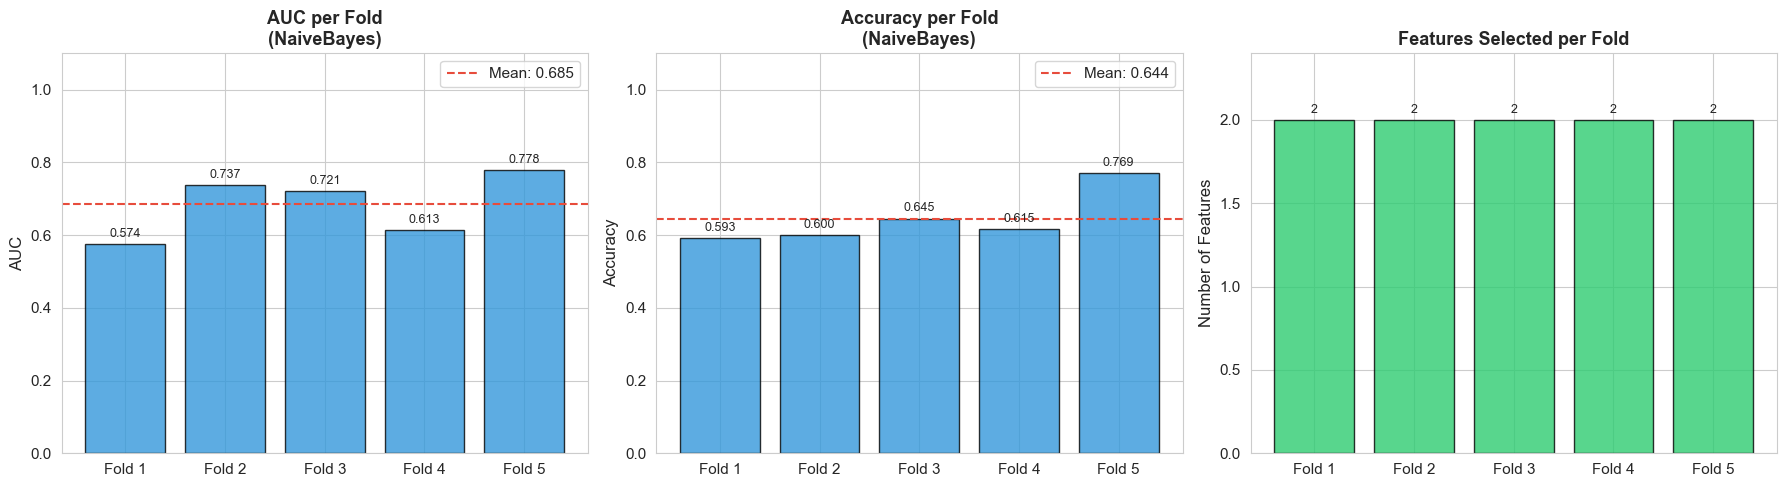


📊 FINAL SUMMARY (NaiveBayes - 5-Fold Cross-Validation)

🔹 AUC:       0.6845 ± 0.0777
   Range: [0.5741, 0.7778]

🔹 Accuracy:  0.6445 ± 0.0649


In [22]:
# =============================================================================
# COHORT GRAPHICAL REPORTING AND FEATURE SELECTION STABILITY MANIFEST
# =============================================================================
# Purpose:
#   - Isolate execution results for the top-performing estimator configuration.
#   - Generate publication-grade, high-resolution tripartite diagnostic charts.
#   - Synthesize a structural feature selection recurrence manifest to evaluate 
#     cross-fold biomarker stability and reproducibility metrics.
# =============================================================================

import os
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply standardized uniform layout parameters for peer-review charting
sns.set_style("whitegrid")

# Dynamically isolate the highest performing configuration matrix pattern
best_model_name = df_summary.iloc[0]['Model'] 
print(f"🤖 Best Model Detected: {best_model_name}\n")

# Filter localized out-of-fold diagnostic matrices matching the top candidate
best_model_folds = df_fold_details[df_fold_details['Model'] == best_model_name].copy()

actual_n_outer = len(best_model_folds)

fold_labels = [f"Fold {int(f)}" for f in best_model_folds['Fold']]
aucs = best_model_folds['AUC'].values
accuracies = best_model_folds['Acc'].values
n_features = best_model_folds['n_features'].values

mean_auc = np.mean(aucs)
mean_acc = np.mean(accuracies)

# --- Subplot 1 to 3: Multi-panel Diagnostic Performance Charts ---------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#3498db'] * actual_n_outer

# 1️⃣ Subplot A: Receiver Operating Characteristic Area Under Curve (AUC)
ax1 = axes[0]
bars1 = ax1.bar(fold_labels, aucs, color=colors, edgecolor='black', alpha=0.8)
ax1.set_ylabel('AUC', fontsize=12)
ax1.set_title(f'AUC per Fold\n({best_model_name})', fontsize=13, fontweight='bold')
ax1.set_ylim(0.0, 1.1)  # Expanded upper boundary to accommodate structural annotation text
ax1.axhline(y=mean_auc, color='#e74c3c', linestyle='--', label=f"Mean: {mean_auc:.3f}")
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
ax1.legend()

# 2️⃣ Subplot B: Empirical Classification Accuracy Profiles
ax2 = axes[1]
bars2 = ax2.bar(fold_labels, accuracies, color=colors, edgecolor='black', alpha=0.8)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title(f'Accuracy per Fold\n({best_model_name})', fontsize=13, fontweight='bold')
ax2.set_ylim(0.0, 1.1)
ax2.axhline(y=mean_acc, color='#e74c3c', linestyle='--', label=f"Mean: {mean_acc:.3f}")
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
ax2.legend()

# 3️⃣ Subplot C: Selected Feature Cardinality Volatility Matrix
ax3 = axes[2]
bars3 = ax3.bar(fold_labels, n_features, color='#2ecc71', edgecolor='black', alpha=0.8)
ax3.set_ylabel('Number of Features', fontsize=12)
ax3.set_title('Features Selected per Fold', fontsize=13, fontweight='bold')
ax3.set_ylim(0, max(n_features) * 1.2 if len(n_features) > 0 else 10)
for bar in bars3:
    height = bar.get_height()
    ax3.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()

# Save structural presentation graphics using extreme high-resolution (DPI 900)
os.makedirs(SAVE_DIR, exist_ok=True)
plot_path = os.path.join(SAVE_DIR, f"best_model_{best_model_name}_folds_report.png")
plt.savefig(plot_path, dpi=900)
print(f"✅ High-resolution plot (DPI 900) saved to: {plot_path}")
plt.show()
plt.close()


# =============================================================================
# COHORT SUMMARY AND INFERENCE CRITERIA TABLES
# =============================================================================
print("\n" + "="*60)
print(f"📊 FINAL SUMMARY ({best_model_name} - {actual_n_outer}-Fold Cross-Validation)")
print("="*60)

print(f"\n🔹 AUC:       {mean_auc:.4f} ± {np.std(aucs):.4f}")
print(f"   Range: [{np.min(aucs):.4f}, {np.max(aucs):.4f}]")

print(f"\n🔹 Accuracy:  {mean_acc:.4f} ± {np.std(accuracies):.4f}")


  DeLong Pairwise AUC Comparison — All Model Pairs
           Model_A            Model_B  AUC_A  AUC_B    ΔAUC Z_stat  p_value Significant (α=0.05) Significant (α=0.01) p_value_bonferroni Significant Bonf. (α=0.05)
        ExtraTrees         SVM_Linear 0.5433 0.6293 -0.0859 -2.616 8.89e-03                    ✓                    ✓           4.00e-01                          ✗
        ExtraTrees            SVM_RBF 0.5433 0.6237 -0.0803 -2.564 1.03e-02                    ✓                    ✗           4.65e-01                          ✗
        ExtraTrees         NaiveBayes 0.5433 0.6512 -0.1078 -2.157 3.10e-02                    ✓                    ✗           1.00e+00                          ✗
        ExtraTrees LogisticRegression 0.5433 0.6192 -0.0759 -2.129 3.33e-02                    ✓                    ✗           1.00e+00                          ✗
        ExtraTrees                KNN 0.5433 0.6210 -0.0777 -1.567 1.17e-01                    ✗                    ✗           1

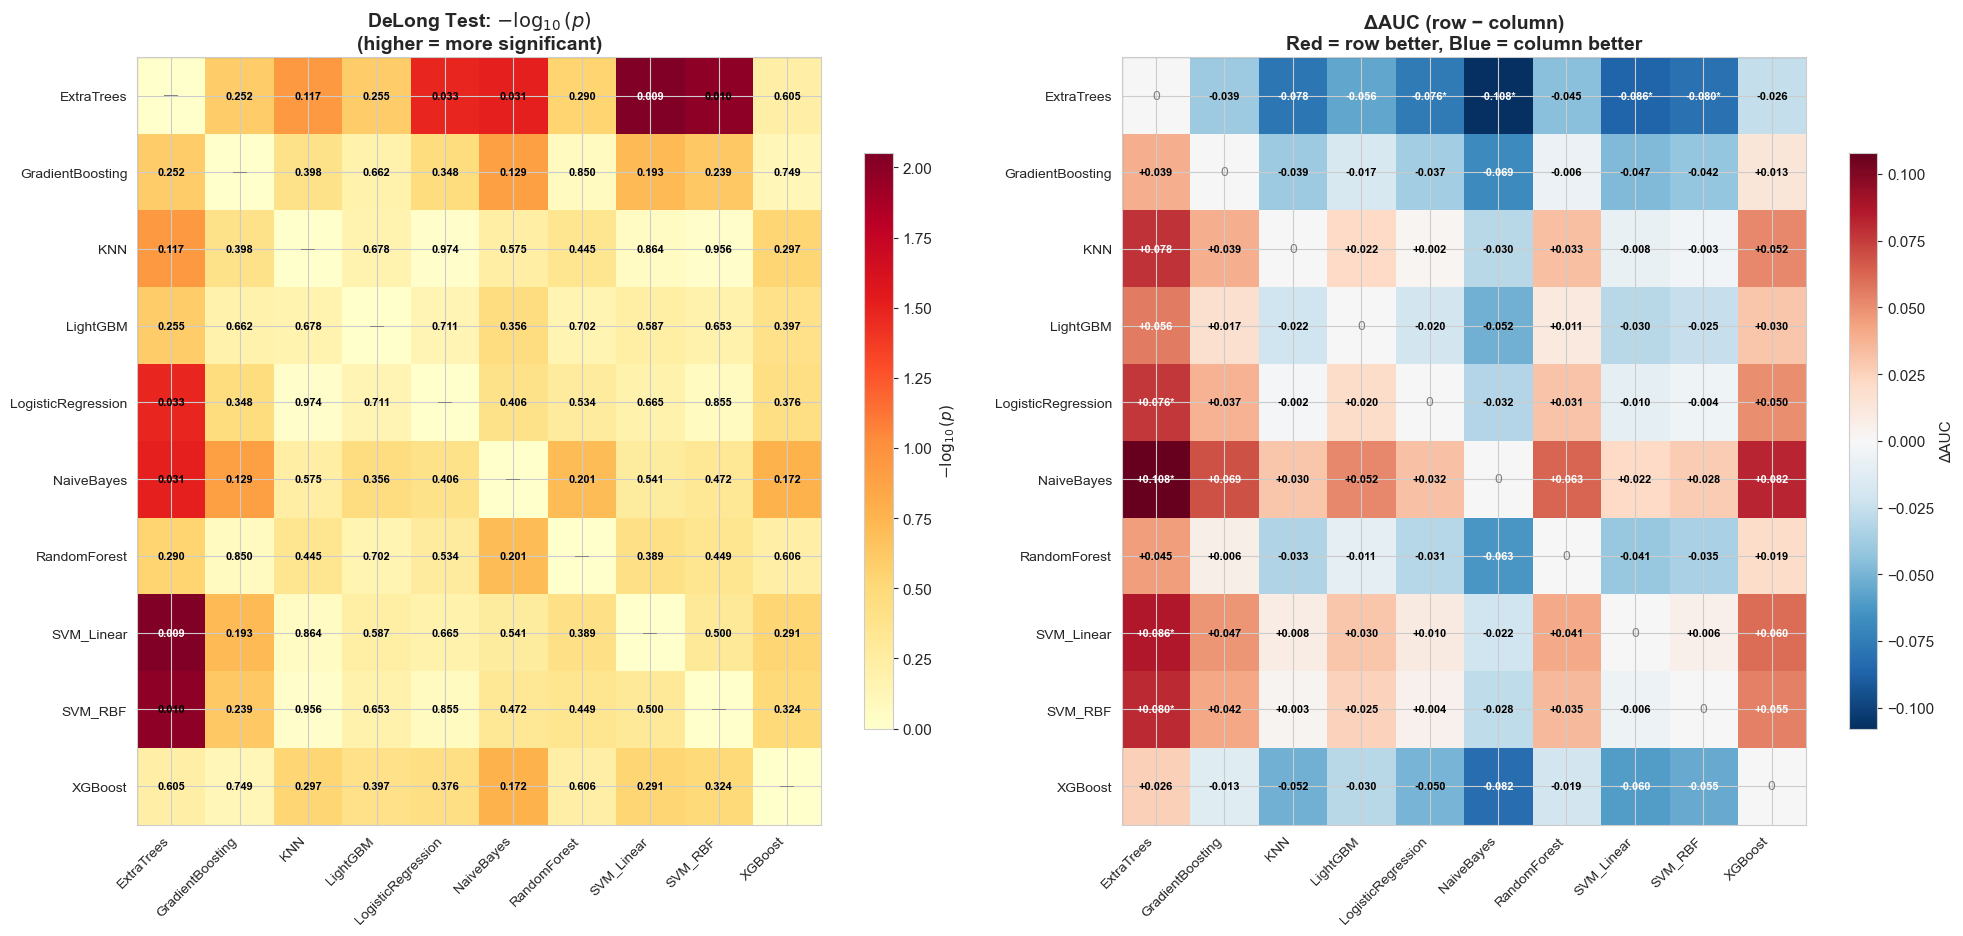


 🏆 Best Model (by Mean AUC): NaiveBayes  (Mean AUC = 0.6845)
 DeLong comparison vs. all other models (sorted by Mean ΔAUC):
        Competitor Competitor_Mean_AUC ΔMean_AUC  p_value p_Bonferroni Significant?
           XGBoost              0.5897   +0.0948 1.72e-01     1.00e+00            ✗
  GradientBoosting              0.5905   +0.0941 1.29e-01     1.00e+00            ✗
        ExtraTrees              0.5955   +0.0890 3.10e-02     1.00e+00            ✓
          LightGBM              0.6046   +0.0800 3.56e-01     1.00e+00            ✗
      RandomForest              0.6277   +0.0568 2.01e-01     1.00e+00            ✗
           SVM_RBF              0.6429   +0.0416 4.72e-01     1.00e+00            ✗
               KNN              0.6548   +0.0297 5.75e-01     1.00e+00            ✗
LogisticRegression              0.6586   +0.0259 4.06e-01     1.00e+00            ✗
        SVM_Linear              0.6617   +0.0229 5.41e-01     1.00e+00            ✗

✅ DeLong analysis complete.


In [23]:
# =============================================================================
# STATISTICAL INFERENCE VIA DELONG PAIRWISE ROC ANALYSIS
# =============================================================================
# Purpose:
#   - Implement vectorized, fast DeLong test computations for paired ROC curves.
#   - Execute exhaustive pairwise model comparisons with family-wise error rate 
#     control via Bonferroni corrections.
#   - Generate publication-grade diagnostic heatmaps tracking p-values and delta AUCs.
#   - Benchmark the top-performing architecture against all remaining cohorts.
# =============================================================================

import os
import warnings
import itertools
from collections import Counter

import numpy as np
import pandas as pd
from scipy import stats

# Enforce strategic default persistence directories if missing from environment context
if 'SAVE_DIR' not in locals() and 'SAVE_DIR' not in globals():
    SAVE_DIR = './nested_cv_outputs'

# -----------------------------------------------------------------------------
# 1. CORE MATH IMPLEMENTATIONS FOR FAST DELONG VECTORIZATION
# -----------------------------------------------------------------------------
def _compute_midrank(x):
    """Computes mathematical midranks for identical entry strings inside vectors."""
    J = np.argsort(x)
    Z = x[J]
    N = len(x)
    T = np.zeros(N, dtype=float)
    i = 0
    while i < N:
        j = i
        while j < N and Z[j] == Z[i]:
            j += 1
        midrank = 0.5 * (i + j - 1)
        for k in range(i, j):
            T[k] = midrank
        i = j
    T2 = np.empty(N, dtype=float)
    T2[J] = T + 1
    return T2


def _fast_delong(predictions_sorted_transposed, label_1_count):
    """Vectorized algorithm mapping structurally unrolled variance-covariance arrays."""
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    k = predictions_sorted_transposed.shape[0]

    tx = np.empty([k, m], dtype=float)
    ty = np.empty([k, n], dtype=float)
    tz = np.empty([k, m + n], dtype=float)

    for r in range(k):
        tz[r] = _compute_midrank(predictions_sorted_transposed[r])
        tx[r] = _compute_midrank(predictions_sorted_transposed[r, :m])
        ty[r] = _compute_midrank(predictions_sorted_transposed[r, m:])

    aucs = tz[:, :m].sum(axis=1) / (m * n) - (m + 1.0) / (2.0 * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m

    sx = np.cov(v01) if k > 1 else np.var(v01, ddof=1).reshape(1, 1)
    sy = np.cov(v10) if k > 1 else np.var(v10, ddof=1).reshape(1, 1)

    delongcov = sx / m + sy / n
    return aucs, delongcov


def delong_roc_test(y_true, y_prob_1, y_prob_2):
    """Executes the standard DeLong test to evaluate two correlated ROC curves.

    Args:
        y_true (np.ndarray): Target true classification outcomes.
        y_prob_1 (np.ndarray): Probability vectors produced by Model 1.
        y_prob_2 (np.ndarray): Probability vectors produced by Model 2.

    Returns:
        dict: Empirical metrics mapping standalone AUCs, Z-scores, and two-tailed p-values.
    """
    y_true = np.asarray(y_true, dtype=np.int64)
    y_prob_1 = np.asarray(y_prob_1, dtype=np.float64)
    y_prob_2 = np.asarray(y_prob_2, dtype=np.float64)

    order = (-y_true).argsort()
    y_true_sorted = y_true[order]
    label_1_count = int(y_true_sorted.sum())

    predictions_sorted_transposed = np.vstack([
        y_prob_1[order],
        y_prob_2[order]
    ])

    aucs, delongcov = _fast_delong(predictions_sorted_transposed, label_1_count)

    diff = aucs[0] - aucs[1]
    var_diff = delongcov[0, 0] + delongcov[1, 1] - 2 * delongcov[0, 1]

    if var_diff <= 0:
        z_stat = 0.0
        p_value = 1.0
    else:
        z_stat = diff / np.sqrt(var_diff)
        p_value = 2.0 * stats.norm.sf(abs(z_stat))

    return {
        'auc1': aucs[0],
        'auc2': aucs[1],
        'z_stat': z_stat,
        'p_value': p_value,
    }


# -----------------------------------------------------------------------------
# 2. PAIRWISE MODEL MATRIX INFERENCE PROTOCOL
# -----------------------------------------------------------------------------
model_names = sorted(nested_cv_results.keys())
n_models = len(model_names)

pvalue_matrix = pd.DataFrame(np.ones((n_models, n_models)), index=model_names, columns=model_names)
zstat_matrix = pd.DataFrame(np.zeros((n_models, n_models)), index=model_names, columns=model_names)

comparison_rows = []
ref_y_true = np.array(nested_cv_results[model_names[0]]['y_true'])

for i, j in itertools.combinations(range(n_models), 2):
    m1, m2 = model_names[i], model_names[j]

    y_true_1 = np.array(nested_cv_results[m1]['y_true'])
    y_true_2 = np.array(nested_cv_results[m2]['y_true'])
    y_prob_1 = np.array(nested_cv_results[m1]['y_prob'])
    y_prob_2 = np.array(nested_cv_results[m2]['y_prob'])

    assert np.array_equal(y_true_1, y_true_2), f"y_true mismatch between {m1} and {m2}!"

    result = delong_roc_test(y_true_1, y_prob_1, y_prob_2)

    pvalue_matrix.loc[m1, m2] = result['p_value']
    pvalue_matrix.loc[m2, m1] = result['p_value']
    zstat_matrix.loc[m1, m2] = result['z_stat']
    zstat_matrix.loc[m2, m1] = -result['z_stat']

    comparison_rows.append({
        'Model_A': m1,
        'Model_B': m2,
        'AUC_A': result['auc1'],
        'AUC_B': result['auc2'],
        'ΔAUC': result['auc1'] - result['auc2'],
        'Z_stat': result['z_stat'],
        'p_value': result['p_value'],
        'Significant (α=0.05)': '✓' if result['p_value'] < 0.05 else '✗',
        'Significant (α=0.01)': '✓' if result['p_value'] < 0.01 else '✗',
    })

df_delong = pd.DataFrame(comparison_rows)
df_delong = df_delong.sort_values('p_value').reset_index(drop=True)

# Enforce rigid Family-Wise Error Rate control using Bonferroni Adjustments
n_comparisons = len(comparison_rows)
df_delong['p_value_bonferroni'] = np.minimum(df_delong['p_value'] * n_comparisons, 1.0)
df_delong['Significant Bonf. (α=0.05)'] = df_delong['p_value_bonferroni'].apply(lambda p: '✓' if p < 0.05 else '✗')


# --- Display Tabular Outputs -------------------------------------------------
print("=" * 90)
print("  DeLong Pairwise AUC Comparison — All Model Pairs")
print("=" * 90)
df_display = df_delong.copy()
df_display['AUC_A'] = df_display['AUC_A'].map('{:.4f}'.format)
df_display['AUC_B'] = df_display['AUC_B'].map('{:.4f}'.format)
df_display['ΔAUC'] = df_display['ΔAUC'].map('{:+.4f}'.format)
df_display['Z_stat'] = df_display['Z_stat'].map('{:.3f}'.format)
df_display['p_value'] = df_display['p_value'].map('{:.2e}'.format)
df_display['p_value_bonferroni'] = df_display['p_value_bonferroni'].map('{:.2e}'.format)
print(df_display.to_string(index=False))

n_sig_005 = (df_delong['p_value'] < 0.05).sum()
n_sig_001 = (df_delong['p_value'] < 0.01).sum()
n_sig_bonf = (df_delong['p_value_bonferroni'] < 0.05).sum()

print(f"\n📊 Summary: {n_comparisons} pairwise comparisons")
print(f"   • Significant at α=0.05:              {n_sig_005}/{n_comparisons}")
print(f"   • Significant at α=0.01:              {n_sig_001}/{n_comparisons}")
print(f"   • Significant after Bonferroni (0.05): {n_sig_bonf}/{n_comparisons}")


# -----------------------------------------------------------------------------
# 3. HIGH-RESOLUTION PRESENTATION HEATMAP GENERATION (DPI 900)
# -----------------------------------------------------------------------------
try:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors

    fig, axes = plt.subplots(1, 2, figsize=(20, 9.5))

    # --- Heatmap Panel A: -log10(p-value) Magnitude Mapping ---
    log_pval = -np.log10(pvalue_matrix.values.astype(float) + 1e-300)
    np.fill_diagonal(log_pval, 0)

    im1 = axes[0].imshow(log_pval, cmap='YlOrRd', aspect='auto')
    axes[0].set_xticks(range(n_models))
    axes[0].set_yticks(range(n_models))
    axes[0].set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
    axes[0].set_yticklabels(model_names, fontsize=10)
    axes[0].set_title('DeLong Test: $-\\log_{10}(p)$\n(higher = more significant)', fontsize=14, fontweight='bold')

    for ii in range(n_models):
        for jj in range(n_models):
            if ii != jj:
                pval = pvalue_matrix.iloc[ii, jj]
                txt = f'{pval:.1e}' if pval < 0.001 else f'{pval:.3f}'
                color = 'white' if log_pval[ii, jj] > 2 else 'black'
                axes[0].text(jj, ii, txt, ha='center', va='center', fontsize=8, color=color, fontweight='bold')
            else:
                axes[0].text(jj, ii, '—', ha='center', va='center', fontsize=10, color='gray')

    fig.colorbar(im1, ax=axes[0], shrink=0.75, label='$-\\log_{10}(p)$')

    # --- Heatmap Panel B: Unrolled Delta AUC Directional Matrix ---
    auc_diff_matrix = pd.DataFrame(np.zeros((n_models, n_models)), index=model_names, columns=model_names)
    for _, row in df_delong.iterrows():
        m1, m2 = row['Model_A'], row['Model_B']
        d = float(row['ΔAUC'])
        auc_diff_matrix.loc[m1, m2] = d
        auc_diff_matrix.loc[m2, m1] = -d

    max_abs = max(abs(auc_diff_matrix.values.min()), abs(auc_diff_matrix.values.max()), 0.01)
    im2 = axes[1].imshow(auc_diff_matrix.values, cmap='RdBu_r', aspect='auto', vmin=-max_abs, vmax=max_abs)
    axes[1].set_xticks(range(n_models))
    axes[1].set_yticks(range(n_models))
    axes[1].set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)
    axes[1].set_yticklabels(model_names, fontsize=10)
    axes[1].set_title('ΔAUC (row − column)\nRed = row better, Blue = column better', fontsize=14, fontweight='bold')

    for ii in range(n_models):
        for jj in range(n_models):
            if ii != jj:
                val = auc_diff_matrix.iloc[ii, jj]
                pval = pvalue_matrix.iloc[ii, jj]
                star = '*' if pval < 0.05 else ''
                txt = f'{val:+.3f}{star}'
                axes[1].text(jj, ii, txt, ha='center', va='center', fontsize=8,
                             color='white' if abs(val) > max_abs * 0.5 else 'black', fontweight='bold')
            else:
                axes[1].text(jj, ii, '0', ha='center', va='center', fontsize=10, color='gray')

    fig.colorbar(im2, ax=axes[1], shrink=0.75, label='ΔAUC')

    for ax in axes:
        ax.axhline(y=-0.5, color='black', linewidth=1.5)
        ax.axvline(x=-0.5, color='black', linewidth=1.5)

    plt.tight_layout()
    
    os.makedirs(SAVE_DIR, exist_ok=True)
    heatmap_save_path = os.path.join(SAVE_DIR, 'delong_pairwise_heatmap.png')
    plt.savefig(heatmap_save_path, dpi=900, bbox_inches='tight')
    print(f"\n💾 High-resolution heatmap (DPI 900) saved to: {heatmap_save_path}")
    plt.show()
    plt.close()

except ImportError:
    print("\n⚠️ matplotlib not available — skipping heatmap visualisation.")


# -----------------------------------------------------------------------------
# 4. CRITICAL CHRONOLOGICAL ANALYSIS: CHOSEN CHAMPION VS INDEPENDENT COHORTS
# -----------------------------------------------------------------------------
mean_aucs = {}
for mn in model_names:
    try:
        # Compute baseline criteria mapping directly on Cross-Validation Fold means
        mean_aucs[mn] = np.mean(nested_cv_results[mn]['fold_aucs'])
    except Exception:
        mean_aucs[mn] = 0.5

# Extract optimal model design index relying exclusively on structural Mean AUC performance
best_model = max(mean_aucs, key=mean_aucs.get)
best_auc = mean_aucs[best_model]

print(f"\n{'=' * 70}")
print(f" 🏆 Best Model (by Mean AUC): {best_model}  (Mean AUC = {best_auc:.4f})")
print(f" DeLong comparison vs. all other models (sorted by Mean ΔAUC):")
print(f"{'=' * 70}")

best_vs_rest = []
for mn in model_names:
    if mn == best_model:
        continue
    
    # Query paired historical database rows matching target experimental configurations
    row_data = df_delong[
        ((df_delong['Model_A'] == best_model) & (df_delong['Model_B'] == mn)) |
        ((df_delong['Model_A'] == mn) & (df_delong['Model_B'] == best_model))
    ]
    
    if len(row_data) > 0:
        row = row_data.iloc[0]
        p_val = row['p_value']
        p_bonf = row['p_value_bonferroni']
    else:
        p_val, p_bonf = 1.0, 1.0

    # Calculate absolute delta values using standalone Mean AUC frame locations
    delta = best_auc - mean_aucs[mn]
    
    best_vs_rest.append({
        'Competitor': mn,
        'Competitor_Mean_AUC': mean_aucs[mn],
        'ΔMean_AUC': delta,
        'p_value': p_val,
        'p_Bonferroni': p_bonf,
        'Significant?': '✓' if p_val < 0.05 else '✗',
    })

# Format and rank baseline comparisons sequentially from largest to minimal delta deviations
df_best_vs_rest = pd.DataFrame(best_vs_rest).sort_values('ΔMean_AUC', ascending=False).reset_index(drop=True)
df_best_vs_rest['Competitor_Mean_AUC'] = df_best_vs_rest['Competitor_Mean_AUC'].map('{:.4f}'.format)
df_best_vs_rest['ΔMean_AUC'] = df_best_vs_rest['ΔMean_AUC'].map('{:+.4f}'.format)
df_best_vs_rest['p_value'] = df_best_vs_rest['p_value'].map('{:.2e}'.format)
df_best_vs_rest['p_Bonferroni'] = df_best_vs_rest['p_Bonferroni'].map('{:.2e}'.format)

print(df_best_vs_rest.to_string(index=False))
print("\n✅ DeLong analysis complete.")

In [24]:
# =============================================================================
# apresentATION-READY METRIC EXTRACTION AND GRAPHICAL PLOTTING INGESTION DATA
# =============================================================================
# Purpose:
#   - Isolate diagnostic metadata, coordinate matrices, and threshold metrics
#     for the top candidate model validated across the outer loops.
#   - Export flat serialization frames (ROC, Precision-Recall, Confusion Matrix).
#   - Build generalized summary statistics integrating Pooled values, Fold means,
#     and corresponding Fold standard deviations to secure strict transparency.
#   - Compress verified assets into a unified artifact bundle for publication.
# =============================================================================

import os
import json
import shutil
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_curve, precision_recall_curve, confusion_matrix, classification_report,
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score
)

# --- 1. Automated Output Destination Initialization -------------------------
save_dir = os.path.join(SAVE_DIR, "plot_data")
os.makedirs(save_dir, exist_ok=True)

# --- 2. Dynamic Champion Model Verification Sequence -------------------------
if 'df_summary' in locals() or 'df_summary' in globals():
    best_model_name = df_summary.iloc[0]['Model']
else:
    best_model_name = list(nested_cv_results.keys())[0]

print(f"📌 Extracting plot data for the BEST MODEL: {best_model_name}\n")

# Isolate execution statistics of the targeted baseline architecture
results = nested_cv_results[best_model_name]

# -----------------------------------------------------------------------------
# 1) Per-Fold Evaluation Records
# -----------------------------------------------------------------------------
if 'df_fold_details' in locals() or 'df_fold_details' in globals():
    pm_df_dynamic = df_fold_details[df_fold_details['Model'] == best_model_name]
    pm_df_dynamic.to_csv(f"{save_dir}/per_fold_metrics.csv", index=False)
    print("[SAVED] per_fold_metrics.csv")
else:
    print("[SKIP] df_fold_details not found, skipping per_fold_metrics.csv")

# -----------------------------------------------------------------------------
# 2) Consolidated Model Cross-Comparison Manifest
# -----------------------------------------------------------------------------
try:
    df_summary.to_csv(f"{save_dir}/model_summary.csv", index=False)
    print("[SAVED] model_summary.csv")
except NameError:
    print("[SKIP] df_summary not found in memory")

# -----------------------------------------------------------------------------
# 3) Pooled Predictions Profile Matrix
# -----------------------------------------------------------------------------
pred_df = pd.DataFrame({
    'y_true': results['y_true'],
    'y_prob': results['y_prob'],
    'y_pred': results['y_pred'],
})
pred_df.to_csv(f"{save_dir}/pooled_predictions.csv", index=False)
print("[SAVED] pooled_predictions.csv")

# -----------------------------------------------------------------------------
# 4) Receiver Operating Characteristic (ROC) Coordinate Curve Values
# -----------------------------------------------------------------------------
fpr, tpr, roc_thresholds = roc_curve(results['y_true'], results['y_prob'])
roc_df = pd.DataFrame({'fpr': fpr, 'tpr': tpr, 'threshold': roc_thresholds})
roc_df.to_csv(f"{save_dir}/roc_curve.csv", index=False)
print("[SAVED] roc_curve.csv")

# -----------------------------------------------------------------------------
# 5) Precision-Recall (PR) Continuous Curve Values
# -----------------------------------------------------------------------------
prec_arr, rec_arr, pr_thresholds = precision_recall_curve(
    results['y_true'], results['y_prob']
)
pr_df = pd.DataFrame({
    'precision': prec_arr,
    'recall':    rec_arr,
    'threshold': np.append(pr_thresholds, np.nan),
})
pr_df.to_csv(f"{save_dir}/pr_curve.csv", index=False)
print("[SAVED] pr_curve.csv")

# -----------------------------------------------------------------------------
# 6) Confusion Matrix Invariant State Coordinates
# -----------------------------------------------------------------------------
cm = confusion_matrix(results['y_true'], results['y_pred'])
cm_df = pd.DataFrame(cm,
                     index=['Actual_0', 'Actual_1'],
                     columns=['Pred_0', 'Pred_1'])
cm_df.to_csv(f"{save_dir}/confusion_matrix.csv")
print("[SAVED] confusion_matrix.csv")

# -----------------------------------------------------------------------------
# 7) Comprehensive Multi-Class Classification JSON Manifest
# -----------------------------------------------------------------------------
cls_report = classification_report(
    results['y_true'], results['y_pred'],
    target_names=['Class_0', 'Class_1'],
    digits=4, output_dict=True
)
with open(f"{save_dir}/classification_report.json", 'w') as f:
    json.dump(cls_report, f, indent=2)
print("[SAVED] classification_report.json")

# -----------------------------------------------------------------------------
# 8) Statistical Summary Matrix (Pooled Metrics, Means, and Standard Deviations)
# -----------------------------------------------------------------------------
summary_stats = {
    'model_name':        best_model_name,
    'n_folds':            len(results['fold_aucs']),
    'n_total_samples':    len(results['y_true']),
    
    # Globally Pooled Descriptive Performance Criteria
    'pooled_auc':           roc_auc_score(results['y_true'], results['y_prob']),
    'pooled_accuracy':      accuracy_score(results['y_true'], results['y_pred']),
    'pooled_bal_accuracy': balanced_accuracy_score(results['y_true'], results['y_pred']),
    'pooled_precision':    precision_score(results['y_true'], results['y_pred'], zero_division=0),
    'pooled_recall':       recall_score(results['y_true'], results['y_pred'], zero_division=0),
    'pooled_f1':           f1_score(results['y_true'], results['y_pred'], zero_division=0),
    'pooled_specificity':  compute_specificity(results['y_true'], results['y_pred']) if 'compute_specificity' in locals() else np.nan,

    # Cross-Fold Arithmetic Mean Performance Matrix Indices
    'mean_fold_auc':          np.mean(results['fold_aucs']),
    'mean_fold_accuracy':     np.mean(results['fold_accuracies']),
    'mean_fold_bal_accuracy':  np.mean(results['fold_bal_accuracies']),
    'mean_fold_precision':    np.mean(results['fold_precisions']),
    'mean_fold_recall':       np.mean(results['fold_recalls']),
    'mean_fold_f1':           np.mean(results['fold_f1_scores']),
    'mean_fold_specificity':  np.mean(results['fold_specificities']),

    # Cross-Fold Parametric Standard Deviations (Structural Stability Margins)
    'std_fold_auc':            np.std(results['fold_aucs']),
    'std_fold_accuracy':       np.std(results['fold_accuracies']),
    'std_fold_bal_accuracy':   np.std(results['fold_bal_accuracies']),
    'std_fold_precision':      np.std(results['fold_precisions']),
    'std_fold_recall':         np.std(results['fold_recalls']),
    'std_fold_f1':             np.std(results['fold_f1_scores']),
    'std_fold_specificity':    np.std(results['fold_specificities']),
}

pd.DataFrame([summary_stats]).to_csv(f"{save_dir}/summary_statistics.csv", index=False)
print("[SAVED] summary_statistics.csv (Includes all Means, Pooled & Stds)")

# -----------------------------------------------------------------------------
# 9) Pack Artifact Repository into a Deployable Package Manifest
# -----------------------------------------------------------------------------
zip_output_name = os.path.join(SAVE_DIR, "plot_data_package")
zip_path = shutil.make_archive(zip_output_name, 'zip', save_dir)
print(f"\n{'='*55}")
print(f"  ALL FILES SAVED IN: {save_dir}/")
print(f"  DOWNLOAD ZIP:       {zip_path}")
print("="*55)

print("\nFiles in package:")
for fname in sorted(os.listdir(save_dir)):
    fsize = os.path.getsize(os.path.join(save_dir, fname))
    print(f"  {fname:35s} ({fsize:,} bytes)")

📌 Extracting plot data for the BEST MODEL: NaiveBayes

[SAVED] per_fold_metrics.csv
[SAVED] model_summary.csv
[SAVED] pooled_predictions.csv
[SAVED] roc_curve.csv
[SAVED] pr_curve.csv
[SAVED] confusion_matrix.csv
[SAVED] classification_report.json
[SAVED] summary_statistics.csv (Includes all Means, Pooled & Stds)

  ALL FILES SAVED IN: ./nested_cv_outputs/plot_data/
  DOWNLOAD ZIP:       /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Models/nested_cv_outputs/plot_data_package.zip

Files in package:
  classification_report.json          (619 bytes)
  confusion_matrix.csv                (45 bytes)
  model_summary.csv                   (4,993 bytes)
  per_fold_metrics.csv                (1,551 bytes)
  pooled_predictions.csv              (2,759 bytes)
  pr_curve.csv                        (6,333 bytes)
  roc_curve.csv                       (3,041 bytes)
  summary_statistics.csv        

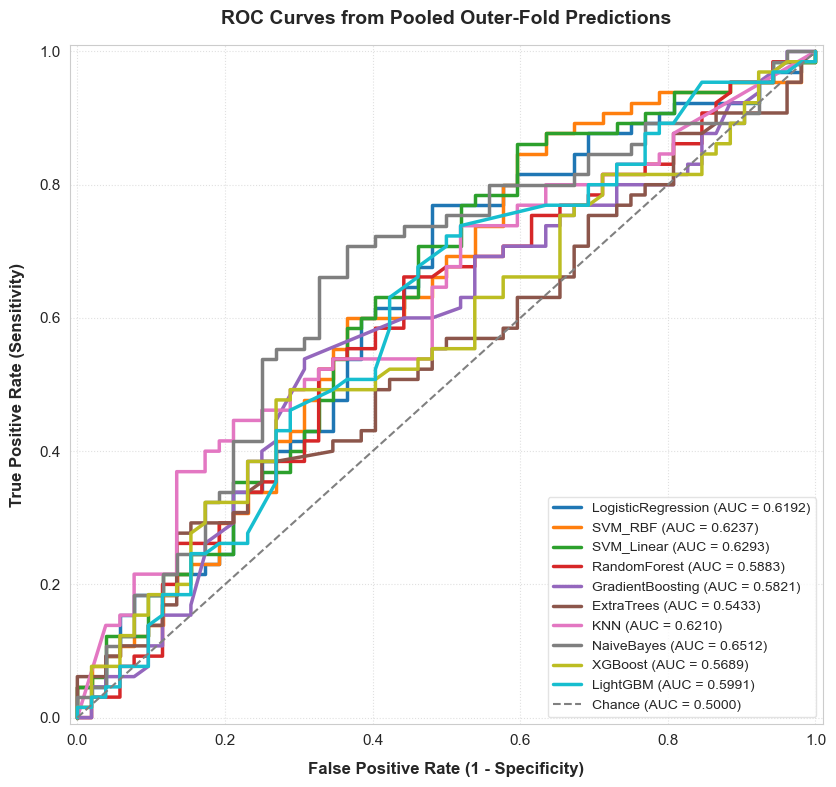


🚀 HIGH-RESOLUTION PLOTS SAVED SUCCESSFULLY:
 🖼️ PNG (DPI 900): ./nested_cv_outputs/roc_curves.png
 📄 PDF (Vector):   ./nested_cv_outputs/roc_curves.pdf


In [25]:
# =============================================================================
# POST-HOC EVALUATION VISUALIZATION: HIGH-RESOLUTION ROC PLOT DESIGN
# =============================================================================
# Purpose:
#   - Aggregate pooled out-of-fold prediction matrices across all core estimators.
#   - Compute exact empirical Receiver Operating Characteristic (ROC) coordinates.
#   - Generate publication-grade, square-proportioned diagnostic curve overlays.
#   - Persist lossless vector PDF sheets and high-density 900 DPI raster matrices.
# =============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# Dynamic asset extraction directory synchronization
PLOT_DIR = CONFIG.get('SAVE_DIR', './nested_cv_outputs')
os.makedirs(PLOT_DIR, exist_ok=True)

# Establish rigorous square geometry aspect configurations optimized for ROC tracking
plt.figure(figsize=(8.5, 8))

# Sequential functional mapping loop navigating through validated cohort predictions
for model_name, results in nested_cv_results.items():
    y_true = np.asarray(results['y_true'])
    y_prob = np.asarray(results['y_prob'])

    # Runtime exception safeguard to filter out unconverged or singular label arrays
    if len(np.unique(y_true)) < 2:
        print(f"⚠️ Skipping ROC for {model_name}: only one class present in y_true.")
        continue

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)

    # Render presentation-ready continuous curves using appropriate lineweights
    plt.plot(fpr, tpr, lw=2.5, label=f"{model_name} (AUC = {auc_val:.4f})")

# Construct baseline random distribution benchmark (Chance Line)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', lw=1.5, label='Chance (AUC = 0.5000)')

# Rigorous layout margin boundary setting
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])

plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('ROC Curves from Pooled Outer-Fold Predictions', fontsize=14, fontweight='bold', pad=15)

# Configure advanced legend to bypass asset collision while securing strict contrast margins
plt.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Absolute multi-format storage target compilation
roc_png = os.path.join(PLOT_DIR, 'roc_curves.png')
roc_pdf = os.path.join(PLOT_DIR, 'roc_curves.pdf')

# Execute dual persistence strategy (DPI 900 Raster + Resolution-Invariant Vector)
plt.savefig(roc_png, dpi=900, bbox_inches='tight')
plt.savefig(roc_pdf, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*50)
print("🚀 HIGH-RESOLUTION PLOTS SAVED SUCCESSFULLY:")
print("="*50)
print(" 🖼️ PNG (DPI 900):", roc_png)
print(" 📄 PDF (Vector):  ", roc_pdf)
print("="*50)

📈 Generating DCA. Best model 'NaiveBayes' will be highlighted.


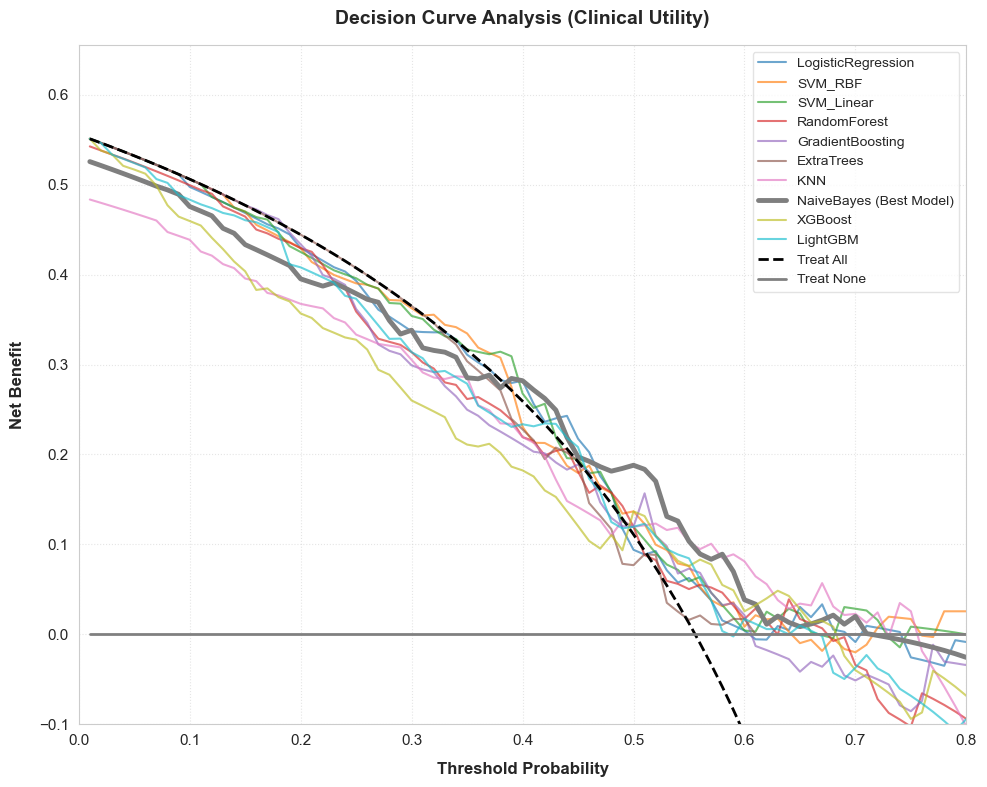


🚀 HIGH-RESOLUTION DCA PLOTS SAVED:
 🖼️ PNG (DPI 900): ./nested_cv_outputs/decision_curve.png
 📄 PDF (Vector):   ./nested_cv_outputs/decision_curve.pdf


In [26]:
# =============================================================================
# POST-HOC EVALUATION VISUALIZATION: HIGH-RESOLUTION DECISION CURVE ANALYSIS
# =============================================================================
# Purpose:
#   - Implement mathematical Net Benefit formulations to evaluate clinical utility.
#   - Contrast dynamic machine learning model configurations against baseline clinical 
#     benchmarks ("Treat All" and "Treat None" strategies).
#   - Dynamically scale line-weights to automatically highlight the champion model.
#   - Save presentation-grade raster PNGs (900 DPI) and vector PDFs.
# =============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt

def decision_curve_net_benefit(y_true, y_prob, thresholds):
    """Computes empirical Net Benefit criteria for specified decision thresholds."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    n = len(y_true)

    net_benefits = []
    for pt in thresholds:
        if pt <= 0 or pt >= 1:
            net_benefits.append(np.nan)
            continue

        y_pred = (y_prob >= pt).astype(int)

        tp = np.sum((y_pred == 1) & (y_true == 1))
        fp = np.sum((y_pred == 1) & (y_true == 0))

        nb = (tp / n) - (fp / n) * (pt / (1 - pt))
        net_benefits.append(nb)

    return np.asarray(net_benefits)


def treat_all_net_benefit(y_true, thresholds):
    """Computes standard reference baseline Net Benefit assuming all patients are treated."""
    y_true = np.asarray(y_true)
    n = len(y_true)
    prevalence = np.mean(y_true)

    net_benefits = []
    for pt in thresholds:
        if pt <= 0 or pt >= 1:
            net_benefits.append(np.nan)
            continue
        nb = prevalence - (1 - prevalence) * (pt / (1 - pt))
        net_benefits.append(nb)

    return np.asarray(net_benefits)


# --- 1. Automated Output Destination Synchronization -------------------------
PLOT_DIR = CONFIG.get('SAVE_DIR', './nested_cv_outputs')
os.makedirs(PLOT_DIR, exist_ok=True)

# --- 2. Dynamic Champion Model Verification Sequence -------------------------
if 'df_summary' in locals() or 'df_summary' in globals():
    best_model_name = df_summary.iloc[0]['Model']
else:
    best_model_name = list(nested_cv_results.keys())[0]

print(f"📈 Generating DCA. Best model '{best_model_name}' will be highlighted.")

thresholds = np.linspace(0.01, 0.99, 99)
plt.figure(figsize=(10, 8))

# Initialize baseline clinical markers relying on the primary validation array
first_model = next(iter(nested_cv_results.keys()))
reference_y_true = np.asarray(nested_cv_results[first_model]['y_true'])
prevalence = np.mean(reference_y_true)

# --- 3. Dynamic Sequential Curve Plotting ------------------------------------
for model_name, results in nested_cv_results.items():
    y_true = np.asarray(results['y_true'])
    y_prob = np.asarray(results['y_prob'])

    # Runtime exception safeguard to filter out unconverged or singular label arrays
    if len(np.unique(y_true)) < 2:
        print(f"⚠️ Skipping DCA for {model_name}: only one class present in y_true.")
        continue

    # Dynamically optimize lineweights to highlight the top-performing candidate
    if model_name == best_model_name:
        lw = 3.5
        alpha = 1.0
        label_str = f"{model_name} (Best Model)"
    else:
        lw = 1.5
        alpha = 0.65
        label_str = model_name
    
    nb_model = decision_curve_net_benefit(y_true, y_prob, thresholds)
    plt.plot(thresholds, nb_model, lw=lw, alpha=alpha, label=label_str)

# --- 4. Clinical Reference Baseline Integration ------------------------------
nb_all = treat_all_net_benefit(reference_y_true, thresholds)
nb_none = np.zeros_like(thresholds)

plt.plot(thresholds, nb_all, linestyle='--', color='black', lw=2, label='Treat All')
plt.plot(thresholds, nb_none, linestyle='-', color='gray', lw=2, label='Treat None')

# Enforce strict medical research layout configuration standards
plt.xlim([0.0, 0.8]) 
plt.ylim([-0.1, max(prevalence + 0.1, 0.5)]) 

plt.xlabel('Threshold Probability', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Net Benefit', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Decision Curve Analysis (Clinical Utility)', fontsize=14, fontweight='bold', pad=15)

# Configure advanced legend matrices for optimal publication clarity
plt.legend(loc='upper right', fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()

# Absolute file path routing
dca_png = os.path.join(PLOT_DIR, 'decision_curve.png')
dca_pdf = os.path.join(PLOT_DIR, 'decision_curve.pdf')

# Execute dual persistence strategy (900 DPI Raster + Resolution-Invariant Vector)
plt.savefig(dca_png, dpi=900, bbox_inches='tight')
plt.savefig(dca_pdf, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*50)
print("🚀 HIGH-RESOLUTION DCA PLOTS SAVED:")
print("="*50)
print(" 🖼️ PNG (DPI 900):", dca_png)
print(" 📄 PDF (Vector):  ", dca_pdf)
print("="*50)

📊 Generating Calibration Curves. Best model 'NaiveBayes' will be highlighted.


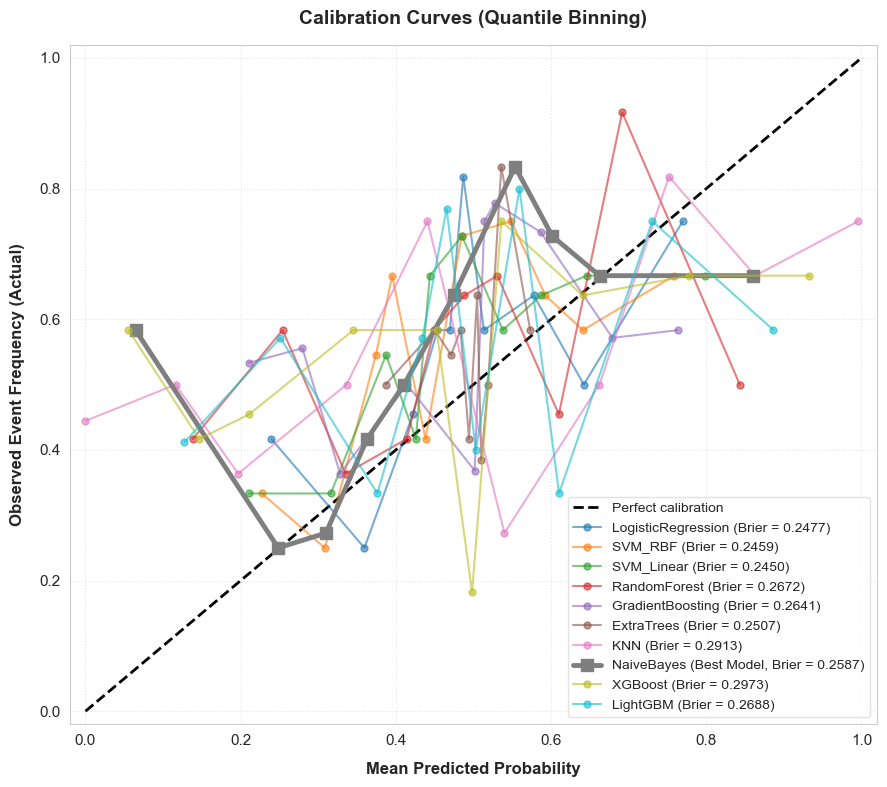


🚀 HIGH-RESOLUTION CALIBRATION PLOTS SAVED:
 🖼️ PNG (DPI 900): ./nested_cv_outputs/calibration_curves.png
 📄 PDF (Vector):   ./nested_cv_outputs/calibration_curves.pdf


In [27]:
# =============================================================================
# POST-HOC EVALUATION VISUALIZATION: HIGH-RESOLUTION CALIBRATION CURVES
# =============================================================================
# Purpose:
#   - Compute exact empirical calibration curves (reliability diagrams) across 
#     all model configurations using quantile binning strategies.
#   - Quantify global calibration performance via Brier Score Loss calculations.
#   - Dynamically highlight the top-performing candidate model using customized 
#     markers, markersizes, and dominant lineweights.
#   - Save production-grade raster PNGs (900 DPI) and vector PDFs.
# =============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# --- 1. Automated Output Destination Synchronization -------------------------
PLOT_DIR = CONFIG.get('SAVE_DIR', './nested_cv_outputs')
os.makedirs(PLOT_DIR, exist_ok=True)

# --- 2. Dynamic Champion Model Verification Sequence -------------------------
if 'df_summary' in locals() or 'df_summary' in globals():
    best_model_name = df_summary.iloc[0]['Model']
else:
    best_model_name = list(nested_cv_results.keys())[0]

print(f"📊 Generating Calibration Curves. Best model '{best_model_name}' will be highlighted.")

n_bins = 10  # Standard clinical deciles of risk distribution
plt.figure(figsize=(9, 8))

# Reference baseline for a theoretically perfect diagnostic model (Perfect Calibration)
plt.plot([0, 1], [0, 1], linestyle='--', color='black', lw=2, label='Perfect calibration')

# --- 3. Dynamic Sequential Calibration Plotting -------------------------------
for model_name, results in nested_cv_results.items():
    y_true = np.asarray(results['y_true'])
    y_prob = np.asarray(results['y_prob'])

    # Runtime exception safeguard to filter out unconverged or singular label arrays
    if len(np.unique(y_true)) < 2:
        print(f"⚠️ Skipping calibration for {model_name}: only one class present in y_true.")
        continue

    try:
        # Enforce quantile strategy to preserve uniform sample counts across cross-validation bins
        frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='quantile')
        brier = brier_score_loss(y_true, y_prob)

        # Dynamically allocate structural lineweights and shapes to emphasize the best model
        if model_name == best_model_name:
            lw = 3.5
            alpha = 1.0
            marker = 's'  # Square marker chosen exclusively for the champion model
            ms = 8
            label_str = f"{model_name} (Best Model, Brier = {brier:.4f})"
        else:
            lw = 1.5
            alpha = 0.6
            marker = 'o'  # Standard circle marker for baseline competitor profiles
            ms = 5
            label_str = f"{model_name} (Brier = {brier:.4f})"

        plt.plot(mean_pred, frac_pos, marker=marker, markersize=ms, lw=lw, alpha=alpha, label=label_str)
        
    except Exception as e:
        print(f"❌ Skipping calibration for {model_name}: {e}")

# Enforce strict layout configuration boundaries
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])

plt.xlabel('Mean Predicted Probability', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Observed Event Frequency (Actual)', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Calibration Curves (Quantile Binning)', fontsize=14, fontweight='bold', pad=15)

# Configure advanced legend matrices for optimal publication clarity
plt.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', edgecolor='gainsboro')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()

# Absolute file path routing
cal_png = os.path.join(PLOT_DIR, 'calibration_curves.png')
cal_pdf = os.path.join(PLOT_DIR, 'calibration_curves.pdf')

# Execute dual persistence strategy (900 DPI Raster + Resolution-Invariant Vector)
plt.savefig(cal_png, dpi=900, bbox_inches='tight')
plt.savefig(cal_pdf, bbox_inches='tight')
plt.show()
plt.close()

print("\n" + "="*50)
print("🚀 HIGH-RESOLUTION CALIBRATION PLOTS SAVED:")
print("="*50)
print(" 🖼️ PNG (DPI 900):", cal_png)
print(" 📄 PDF (Vector):  ", cal_pdf)
print("="*50)

In [28]:
# =============================================================================
# COHORT ARTIFACT PERSISTENCE AND CROSS-MODEL EVALUATION EXTRACTOR
# =============================================================================
# Purpose:
#   - Atomically validate array distributions and nomenclature consistency.
#   - Export isolated vector matrices (ROC, PR-Curve, Confusion Matrices) 
#     separately for each individual model topology in the execution memory.
#   - Compute stratified descriptive macro-parameters (mean, std, min, max, pooled).
#   - Persist cross-model evaluation rankings to secure tabular outputs.
# =============================================================================

import os
import json
import warnings
import numpy as np
import pandas as pd

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    accuracy_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score
)

# -----------------------------------------------------------------------------
# 1. COMPONSATIONAL VALIDATION AND DATA ALIGNMENT UTILITY FUNCTIONS
# -----------------------------------------------------------------------------

def safe_array(x):
    """Converts upstream iterable objects cleanly into 1D contiguous NumPy arrays."""
    if x is None:
        return np.array([])
    return np.asarray(x).ravel()


def safe_metric_stats(values):
    """Computes robust descriptive parameters for localized fold evaluation records.

    Safeguards downstream IO processes from crashing when encountered with empty 
    or incomplete cross-validation tracks by adaptively embedding NaN limits.
    """
    if values is None:
        return np.nan, np.nan, np.nan, np.nan
    
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return np.nan, np.nan, np.nan, np.nan
    
    return (
        float(np.mean(values)),
        float(np.std(values)),
        float(np.min(values)),
        float(np.max(values))
    )


def get_optional_metric(results, key, model_name=None):
    """Safely extracts supplementary non-mandatory metrics from execution arrays."""
    if key not in results or results[key] is None or len(results[key]) == 0:
        warnings.warn(
            f"[{model_name}] Optional metric '{key}' not found in results. "
            f"Summary values will be saved as NaN."
        )
        return []
    return results[key]


def validate_required_keys(results, required_keys, model_name="unknown_model"):
    """Enforces rigid metadata verification to protect analytical structural integrity."""
    missing = [k for k in required_keys if k not in results]
    if missing:
        raise ValueError(
            f"Model '{model_name}' is missing required keys in results: {missing}"
        )


# -----------------------------------------------------------------------------
# 2. CORE SERIALIZATION ENGINE FOR ARTIFACT GENERATION
# -----------------------------------------------------------------------------
def save_model_data(model_name, results, base_dir='plot_data'):
    """Atomically exports performance plots, vector logs, and meta-logs for a model.

    Args:
        model_name (str): Matching token matching the target estimator signature.
        results (dict): Log tracking historical prediction matrices and fold outputs.
        base_dir (str): Relative destination path defining asset storage boundaries.

    Returns:
        dict: Flattened composite mapping consisting of pooled indices and fold statistics.
    """
    required_keys = [
        'y_true', 'y_prob', 'y_pred',
        'fold_aucs', 'fold_accuracies',
        'fold_f1_scores', 'fold_precisions', 'fold_recalls',
        'n_features_per_fold'
    ]
    validate_required_keys(results, required_keys, model_name)

    model_dir = os.path.join(base_dir, model_name)
    os.makedirs(model_dir, exist_ok=True)

    y_true = safe_array(results['y_true'])
    y_prob = safe_array(results['y_prob'])
    y_pred = safe_array(results['y_pred'])

    if len(y_true) == 0:
        raise ValueError(f"Model '{model_name}' has empty y_true.")
    if not (len(y_true) == len(y_prob) == len(y_pred)):
        raise ValueError(
            f"Model '{model_name}' has inconsistent lengths: "
            f"len(y_true)={len(y_true)}, len(y_prob)={len(y_prob)}, len(y_pred)={len(y_pred)}"
        )

    # Ingest complementary auxiliary fold sequences
    fold_pr_aucs = get_optional_metric(results, 'fold_pr_aucs', model_name=model_name)
    fold_bal_accuracies = get_optional_metric(results, 'fold_bal_accuracies', model_name=model_name)

    # ─── 1. Receiver Operating Characteristic (ROC) Coordinate Curves ───
    fpr, tpr, thresholds_roc = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr, tpr)

    roc_df = pd.DataFrame({
        'fpr': fpr,
        'tpr': tpr
    })
    roc_df['threshold'] = np.nan
    roc_df.iloc[:len(thresholds_roc), roc_df.columns.get_loc('threshold')] = thresholds_roc
    roc_df.to_csv(os.path.join(model_dir, 'roc_curve.csv'), index=False)

    # ─── 2. Precision-Recall (PR) Continuous Curve Values ───
    precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_true, y_prob)
    ap_score = average_precision_score(y_true, y_prob)

    pr_df = pd.DataFrame({
        'precision': precision_curve,
        'recall': recall_curve
    })
    pr_df['threshold'] = np.nan
    pr_df.iloc[:len(thresholds_pr), pr_df.columns.get_loc('threshold')] = thresholds_pr
    pr_df.to_csv(os.path.join(model_dir, 'pr_curve.csv'), index=False)

    # ─── 3. Invariant State Confusion Matrices ───
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(
        cm,
        index=['Actual_0', 'Actual_1'],
        columns=['Predicted_0', 'Predicted_1']
    )
    cm_df.to_csv(os.path.join(model_dir, 'confusion_matrix.csv'))

    # ─── 4. Pooled Prediction Tracking Profiles ───
    pooled_df = pd.DataFrame({
        'y_true': y_true,
        'y_prob': y_prob,
        'y_pred': y_pred
    })
    pooled_df.to_csv(os.path.join(model_dir, 'pooled_predictions.csv'), index=False)

    # ─── 5. High-Fidelity Categorization Reports (JSON Manifest) ───
    report = classification_report(y_true, y_pred, output_dict=True)
    report['roc_auc'] = float(roc_auc)
    report['average_precision'] = float(ap_score)
    report['balanced_accuracy'] = float(balanced_accuracy_score(y_true, y_pred))

    with open(os.path.join(model_dir, 'classification_report.json'), 'w') as f:
        json.dump(report, f, indent=2)

    # ─── 6. Structural Longitudinal Fold Progress Matrix ───
    n_folds = len(results['fold_aucs'])

    fold_data = {
        'fold': list(range(1, n_folds + 1)),
        'auc': list(results['fold_aucs']),
        'pr_auc': list(fold_pr_aucs) if len(fold_pr_aucs) == n_folds else [np.nan] * n_folds,
        'accuracy': list(results['fold_accuracies']),
        'bal_accuracy': list(fold_bal_accuracies) if len(fold_bal_accuracies) == n_folds else [np.nan] * n_folds,
        'f1_score': list(results['fold_f1_scores']),
        'precision': list(results['fold_precisions']),
        'recall': list(results['fold_recalls']),
        'n_features': list(results['n_features_per_fold']),
    }

    fold_df = pd.DataFrame(fold_data)
    fold_df.to_csv(os.path.join(model_dir, 'per_fold_metrics.csv'), index=False)

    # ─── 7. Optimal Dynamic Hyperparameter Log Maps ───
    if results.get('best_params_per_fold') is not None and len(results.get('best_params_per_fold')) > 0:
        params_df = pd.DataFrame(results['best_params_per_fold'])
        params_df.insert(0, 'fold', range(1, len(params_df) + 1))
        params_df.to_csv(os.path.join(model_dir, 'best_params_per_fold.csv'), index=False)

    # ─── 8. Summary Statistics Tabular Matrix Construction ───
    auc_mean, auc_std, auc_min, auc_max = safe_metric_stats(results['fold_aucs'])
    pr_mean, pr_std, pr_min, pr_max = safe_metric_stats(fold_pr_aucs)
    acc_mean, acc_std, acc_min, acc_max = safe_metric_stats(results['fold_accuracies'])
    bal_mean, bal_std, bal_min, bal_max = safe_metric_stats(fold_bal_accuracies)
    f1_mean, f1_std, f1_min, f1_max = safe_metric_stats(results['fold_f1_scores'])
    prec_mean, prec_std, prec_min, prec_max = safe_metric_stats(results['fold_precisions'])
    rec_mean, rec_std, rec_min, rec_max = safe_metric_stats(results['fold_recalls'])

    summary = {
        'metric': ['AUC', 'PR_AUC', 'Accuracy', 'Bal_Accuracy', 'F1_Score', 'Precision', 'Recall'],
        'mean':   [auc_mean, pr_mean, acc_mean, bal_mean, f1_mean, prec_mean, rec_mean],
        'std':    [auc_std,  pr_std, acc_std, bal_std, f1_std, prec_std, rec_std],
        'min':    [auc_min,  pr_min, acc_min, bal_min, f1_min, prec_min, rec_min],
        'max':    [auc_max,  pr_max, acc_max, bal_max, f1_max, prec_max, rec_max],
        'pooled': [
            float(roc_auc),
            float(ap_score),  # Maps pooled PR-AUC / Average Precision criteria
            float(accuracy_score(y_true, y_pred)),
            float(balanced_accuracy_score(y_true, y_pred)),
            float(f1_score(y_true, y_pred)),
            float(precision_score(y_true, y_pred, zero_division=0)),
            float(recall_score(y_true, y_pred, zero_division=0)),
        ]
    }

    summary_df = pd.DataFrame(summary)
    summary_df.to_csv(os.path.join(model_dir, 'summary_statistics.csv'), index=False)

    return {
        'pooled_auc': float(roc_auc),
        'pooled_pr_auc': float(ap_score),
        'pooled_accuracy': float(accuracy_score(y_true, y_pred)),
        'pooled_bal_accuracy': float(balanced_accuracy_score(y_true, y_pred)),
        'pooled_f1': float(f1_score(y_true, y_pred)),
        'pooled_precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'pooled_recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'n_samples': int(len(y_true)),
        'n_folds': int(n_folds),
        'fold_auc_mean': auc_mean,
        'fold_auc_std': auc_std,
        'fold_pr_auc_mean': pr_mean,
        'fold_pr_auc_std': pr_std,
        'fold_accuracy_mean': acc_mean,
        'fold_accuracy_std': acc_std,
        'fold_bal_accuracy_mean': bal_mean,
        'fold_bal_accuracy_std': bal_std,
        'fold_f1_mean': f1_mean,
        'fold_f1_std': f1_std,
        'fold_precision_mean': prec_mean,
        'fold_precision_std': prec_std,
        'fold_recall_mean': rec_mean,
        'fold_recall_std': rec_std,
    }


# -----------------------------------------------------------------------------
# 3. GLOBAL ROUTING PIPELINE SEQUENCE: SYSTEM OVERVIEW LOGGING
# -----------------------------------------------------------------------------
base_dir = 'plot_data'
os.makedirs(base_dir, exist_ok=True)

print("=" * 70)
print("📦 Saving data for all models...")
print("=" * 70)

all_models_summary = []

for model_name, results in nested_cv_results.items():
    try:
        if 'y_true' not in results or len(results['y_true']) == 0:
            print(f"  ⚠️  {model_name}: No data found, skipping...")
            continue

        model_summary = save_model_data(model_name, results, base_dir)

        all_models_summary.append({
            'model': model_name,
            'mean_auc': model_summary['fold_auc_mean'],
            'std_auc': model_summary['fold_auc_std'],
            'pooled_auc': model_summary['pooled_auc'],
            'mean_pr_auc': model_summary['fold_pr_auc_mean'],
            'std_pr_auc': model_summary['fold_pr_auc_std'],
            'pooled_pr_auc': model_summary['pooled_pr_auc'],
            'mean_accuracy': model_summary['fold_accuracy_mean'],
            'std_accuracy': model_summary['fold_accuracy_std'],
            'pooled_accuracy': model_summary['pooled_accuracy'],
            'mean_bal_accuracy': model_summary['fold_bal_accuracy_mean'],
            'std_bal_accuracy': model_summary['fold_bal_accuracy_std'],
            'pooled_bal_accuracy': model_summary['pooled_bal_accuracy'],
            'mean_f1': model_summary['fold_f1_mean'],
            'std_f1': model_summary['fold_f1_std'],
            'pooled_f1': model_summary['pooled_f1'],
            'mean_precision': model_summary['fold_precision_mean'],
            'std_precision': model_summary['fold_precision_std'],
            'pooled_precision': model_summary['pooled_precision'],
            'mean_recall': model_summary['fold_recall_mean'],
            'std_recall': model_summary['fold_recall_std'],
            'pooled_recall': model_summary['pooled_recall'],
            'n_samples': model_summary['n_samples'],
            'n_folds': model_summary['n_folds'],
        })

        print(
            f"   ✅ {model_name:25s} | "
            f"Pooled AUC={model_summary['pooled_auc']:.4f} | "
            f"Pooled PR-AUC={model_summary['pooled_pr_auc']:.4f} | "
            f"{model_summary['n_samples']} samples | "
            f"{model_summary['n_folds']} folds"
        )

    except Exception as e:
        print(f"   ❌ {model_name}: Failed -> {e}")


# -----------------------------------------------------------------------------
# 4. CROSS-MODEL TABULAR RANKING MATRIX EVALUATION
# -----------------------------------------------------------------------------
comparison_dir = os.path.join(base_dir, 'comparison')
os.makedirs(comparison_dir, exist_ok=True)

summary_all_df = pd.DataFrame(all_models_summary)

if len(summary_all_df) > 0:
    summary_all_df = summary_all_df.sort_values('mean_auc', ascending=False).reset_index(drop=True)
    summary_all_df.to_csv(os.path.join(comparison_dir, 'all_models_summary.csv'), index=False)

print("=" * 70)
print(f"✅ Done! {len(all_models_summary)} models saved.")
print(f"📁 Output directory: {os.path.abspath(base_dir)}")
print("=" * 70)

# --- Dynamic Directory Verification Sequence ---------------------------------
print("\n📂 Directory structure:")
for item_name in sorted(os.listdir(base_dir)):
    item_path = os.path.join(base_dir, item_name)
    if os.path.isdir(item_path):
        files = os.listdir(item_path)
        print(f"   ├── {item_name}/ ({len(files)} files)")

📦 Saving data for all models...
   ✅ LogisticRegression        | Pooled AUC=0.6192 | Pooled PR-AUC=0.6604 | 117 samples | 5 folds
   ✅ SVM_RBF                   | Pooled AUC=0.6237 | Pooled PR-AUC=0.6603 | 117 samples | 5 folds
   ✅ SVM_Linear                | Pooled AUC=0.6293 | Pooled PR-AUC=0.6661 | 117 samples | 5 folds
   ✅ RandomForest              | Pooled AUC=0.5883 | Pooled PR-AUC=0.6170 | 117 samples | 5 folds
   ✅ GradientBoosting          | Pooled AUC=0.5821 | Pooled PR-AUC=0.6156 | 117 samples | 5 folds
   ✅ ExtraTrees                | Pooled AUC=0.5433 | Pooled PR-AUC=0.6288 | 117 samples | 5 folds
   ✅ KNN                       | Pooled AUC=0.6210 | Pooled PR-AUC=0.6773 | 117 samples | 5 folds
   ✅ NaiveBayes                | Pooled AUC=0.6512 | Pooled PR-AUC=0.6835 | 117 samples | 5 folds
   ✅ XGBoost                   | Pooled AUC=0.5689 | Pooled PR-AUC=0.6365 | 117 samples | 5 folds
   ✅ LightGBM                  | Pooled AUC=0.5991 | Pooled PR-AUC=0.6266 | 117 sample

In [29]:
# =============================================================================
# RADIOMICS MANIFOLD LEARNING AND HIGH-DIMENSIONAL COHORT CLUSTERING (t-SNE)
# =============================================================================
# Purpose:
#   - Isolate raw numeric multi-modality features from global diagnostic frames.
#   - Execute non-linear dimensionality reduction utilizing manifold learning (t-SNE).
#   - Generate presentation-grade, high-resolution diagnostic cluster charts 
#     evaluating class boundaries (0 vs 1) and intra-patient batch effects.
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# --- 1. Vector Matrix Isolation and Baseline Extraction ---------------------
# Filter continuous numeric radiomics parameters dynamically from system memory
X_numeric = df.select_dtypes(include=[np.number])
y_labels = y
patient_groups = groups

print("⏳ Scaling data and calculating t-SNE (This may take 1-2 minutes)...")

# --- 2. Invariant Standardization and Feature Rescaling ---------------------
# Enforce zero-mean and unit-variance scaling to protect optimization algorithms 
# from dominant dimensional variance artifacts.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# --- 3. Manifold Learning and Low-Dimensional Embedding Space ----------------
# Compile non-linear high-dimensional topological boundaries into an optimized 
# 2D coordinate map using t-Distributed Stochastic Neighbor Embedding.
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

# Assemble lower-dimensional array coordinates into a clean structured tracking DataFrame
tsne_df = pd.DataFrame({
    'TSNE_1': X_tsne[:, 0],
    'TSNE_2': X_tsne[:, 1],
    'Class': y_labels,
    'Patient_ID': patient_groups
})

# Establish destination directory framework for persistent storage
os.makedirs('plot_data/Clustering', exist_ok=True)

# -----------------------------------------------------------------------------
# GRAPHICAL CHART 1: TARGET PATHOLOGICAL SIGNAL ISOLATION ANALYSIS
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE_1', y='TSNE_2',
    hue='Class',
    palette=['#FF7043', '#00ACC1'],  # Balanced vibrant coral and deep cyan accents
    data=tsne_df,
    alpha=0.7,
    s=60,
    edgecolor=None
)
plt.title("t-SNE Visualization: Separation by Class (0 vs 1)", fontsize=14, pad=15)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)
plt.legend(title='Target Class')
plt.tight_layout()
plt.savefig('plot_data/Clustering/tsne_by_class.png', dpi=300)
plt.close()

# -----------------------------------------------------------------------------
# GRAPHICAL CHART 2: INTRA-PATIENT LESION CLUSTERING MATRIX
# -----------------------------------------------------------------------------
plt.figure(figsize=(12, 9))
sns.scatterplot(
    x='TSNE_1', y='TSNE_2',
    hue='Patient_ID',
    palette='tab20',  # Distinct qualitative layout to track discrete subject profiles
    data=tsne_df,
    alpha=0.8,
    s=50,
    edgecolor='k',
    linewidth=0.2
)
plt.title("t-SNE Visualization: Lesion Clustering by Patient", fontsize=14, pad=15)
plt.xlabel("t-SNE Dimension 1", fontsize=12)
plt.ylabel("t-SNE Dimension 2", fontsize=12)

# Prevent bounding-box metric clipping by projecting the legend externally
plt.legend(title='Patient ID', bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=2)
plt.tight_layout()
plt.savefig('plot_data/Clustering/tsne_by_patient.png', dpi=900)
plt.close()

print("✅ t-SNE plots saved successfully in 'plot_data/Clustering/'")

⏳ Scaling data and calculating t-SNE (This may take 1-2 minutes)...
✅ t-SNE plots saved successfully in 'plot_data/Clustering/'


Background dataset has 117 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=117 when initializing the masker.


🌟 FINAL PIPELINE: SHAP ANALYSIS FOR BEST MODEL (BY MEAN AUC)
✅ Final pipeline verified. Operating on 7 active features.
🏆 Champion Model Detected (by Mean AUC): NaiveBayes
📈 Mean AUC Score: 0.6845

🚀 Training final NaiveBayes model on 7 stable features...
💾 Trained model safely stored at: ./nested_cv_outputs/Best_Model_NaiveBayes_Final.joblib

📊 Evaluating Final Model Agreement Profile...
--------------------------------------------------
🎯 Final Model Accuracy: 0.6154
🔮 Cohen's Kappa Value:  0.1718
📢 Agreement Quality:    Slight Agreement (Very Weak)
--------------------------------------------------

⏳ Calculating SHAP values...


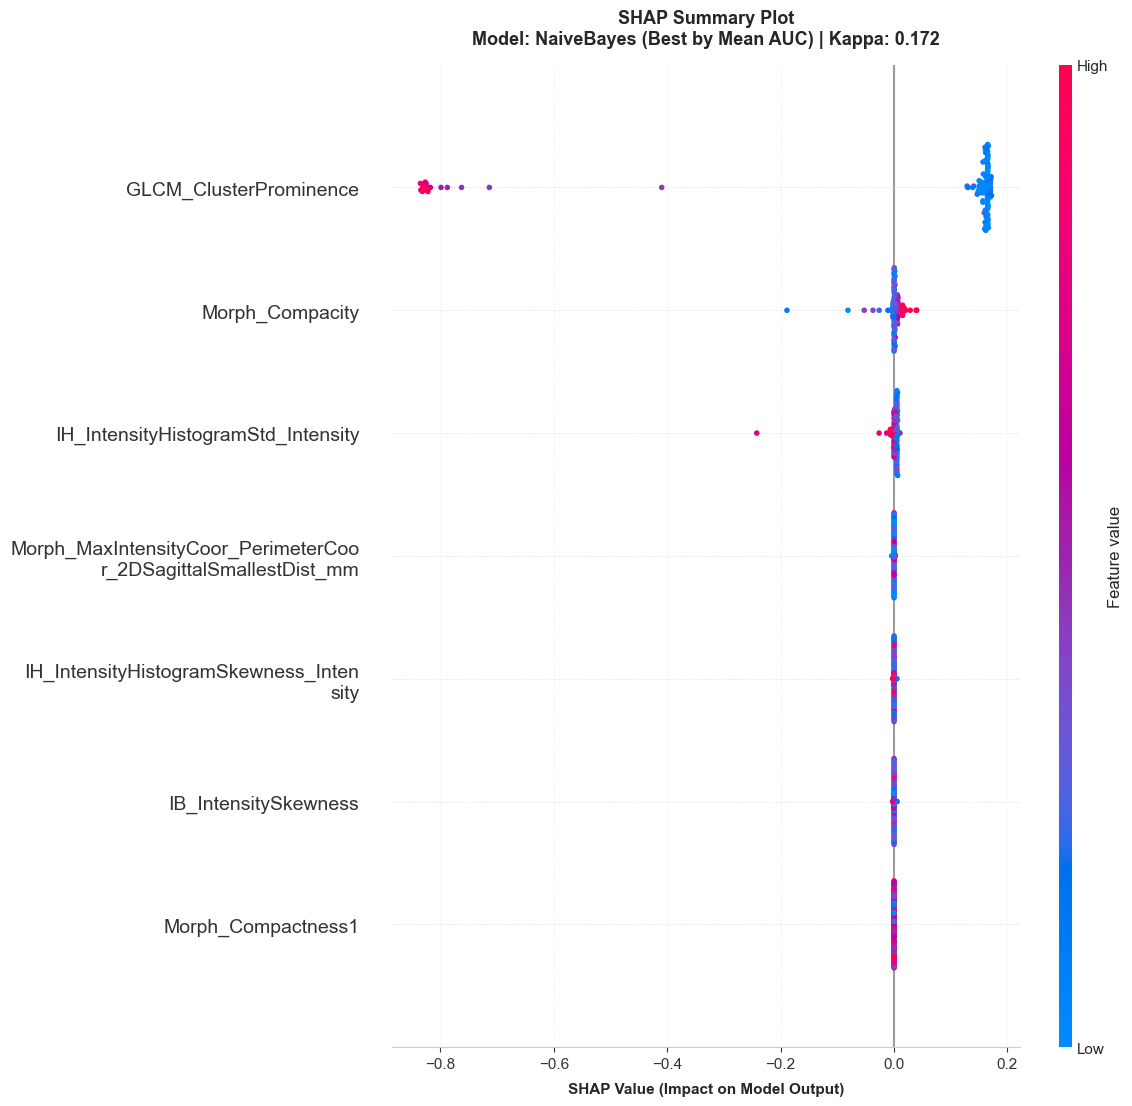

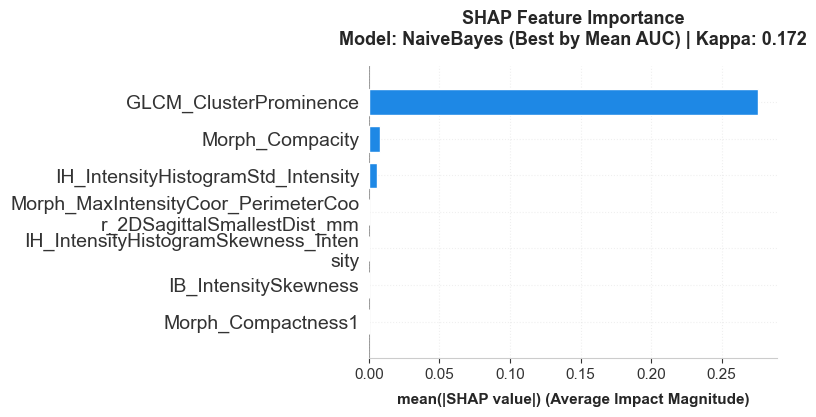

🎉 SHAP PIPELINE COMPLETE WITH ORIGINAL DESIGN!
📁 Plots stored at: ./nested_cv_outputs/SHAP_Plots


In [30]:
# =============================================================================
# FINAL EXPLAINABLE AI (XAI) MODULE: SHAP ANALYSIS & AGREEMENT PROFILING
# =============================================================================
# Purpose:
#   - Isolate the structural intersection of cross-fold stable radiomics features.
#   - Automatically extract the champion model architecture based on Mean AUC profiles.
#   - Re-train the optimal estimator configuration on the finalized stable feature space.
#   - Quantify model classification agreement via Cohen's Kappa statistics.
#   - Generate publication-grade high-resolution SHAP Summary and Bar Importance plots.
# =============================================================================

import os
import re
import textwrap
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import cohen_kappa_score, accuracy_score

print("=" * 60)
print("🌟 FINAL PIPELINE: SHAP ANALYSIS FOR BEST MODEL (BY MEAN AUC)")
print("=" * 60)

# -----------------------------------------------------------------------------
# 1. MATHEMATICAL INTERPRETATION AND STRING PACKING UTILITIES
# -----------------------------------------------------------------------------
def interpret_kappa(kappa_score):
    """Provides standard categorization for Cohen's Kappa agreement levels."""
    if kappa_score < 0:
        return "No Agreement (Worst than chance)"
    elif kappa_score <= 0.20:
        return "Slight Agreement (Very Weak)"
    elif kappa_score <= 0.40:
        return "Fair Agreement (Low)"
    elif kappa_score <= 0.60:
        return "Moderate Agreement (Acceptable)"
    elif kappa_score <= 0.80:
        return "Substantial Agreement (Strong)"
    else:
        return "Almost Perfect Agreement (Excellent)"


def wrap_feature_labels(labels, width=35):
    """Enforces dynamic multi-line wrapping to preserve text bounding boxes in plots."""
    return [textwrap.fill(str(label), width=width) for label in labels]


def clean_forbidden_chars(name):
    """Substitutes illegal matrix syntax symbols with standard underscores."""
    name = str(name)
    name = re.sub(r'[\[\]<>]', '_', name)
    return name


# -----------------------------------------------------------------------------
# 2. STABLE FEATURE SPACE CONSOLIDATION AND ALIGNMENT MATRIX
# -----------------------------------------------------------------------------
all_selected_features = []
for fold_features in selected_features_per_fold:
    all_selected_features.extend(fold_features)

unique_stable_features = list(set(all_selected_features))

# Administration and administrative tracking keys exclusion manifest
unwanted_cols = [
    CONFIG['LABEL_COL'],
    CONFIG['GROUP_COL'],
    'Unnamed: 0', 'id', 'ID', 'Batch', 'INFO_NameOfRoi', 'INFO_NameOfRoi_PET', 'INFO_PatientName_PET', 'Batch_PET',
    'PET2_INTENSITY-HISTOGRAM_MaximumHistogramGradient(IBSI:12CE)[Intensity]',
    'CT_INTENSITY-BASED_TotalLesionGlycolysis(IBSI:No)[]'
]

clean_features = []
for f in unique_stable_features:
    if f in df.columns and f not in unwanted_cols:
        clean_features.append(f)
    else:
        base_f = re.sub(r'(_PET|_CT)$', '', str(f))
        for col in df.columns:
            if col not in unwanted_cols and base_f in str(col):
                if col not in clean_features:
                    clean_features.append(col)

# Fallback scenario execution if nomenclature collisions empty the active space
if len(clean_features) == 0:
    print("⚠️ Warning: Stable features list was empty due to column renaming mismatch.")
    print("💡 Fallback: Using all available numeric radiomics features automatically.")
    clean_features = [c for c in df.columns if c not in unwanted_cols and df[c].dtype in ['float64', 'float32', 'int64', 'int32']]

print(f"✅ Final pipeline verified. Operating on {len(clean_features)} active features.")

X_final_stable = df[clean_features].copy()
y_final = y

X_for_model = X_final_stable.copy()
X_for_model.columns = [clean_forbidden_chars(c) for c in X_for_model.columns]


# -----------------------------------------------------------------------------
# 3. DYNAMIC CHAMPION SELECTION AND HYPERPARAMETER INGESTION
# -----------------------------------------------------------------------------
mean_aucs = {}
for mn in sorted(nested_cv_results.keys()):
    try:
        mean_aucs[mn] = np.mean(nested_cv_results[mn]['fold_aucs'])
    except Exception:
        mean_aucs[mn] = 0.5

best_model_name = max(mean_aucs, key=mean_aucs.get)
best_model_results = nested_cv_results[best_model_name]

print(f"🏆 Champion Model Detected (by Mean AUC): {best_model_name}")
print(f"📈 Mean AUC Score: {mean_aucs[best_model_name]:.4f}")

# Extract best hyperparameter vectors corresponding to the highest validation loop track
best_fold_idx = np.argmax(best_model_results['fold_aucs'])
best_params = best_model_results['best_params_per_fold'][best_fold_idx]


# -----------------------------------------------------------------------------
# 4. ATOMIC COHORT ESTIMATOR RE-TRAINING & JOB PERSISTENCE
# -----------------------------------------------------------------------------
model_template = NESTED_CV_MODELS[best_model_name]
final_model = type(model_template)(**best_params)

print(f"\n🚀 Training final {best_model_name} model on {len(clean_features)} stable features...")
import re

X_for_model.columns = [
    re.sub(r'[^a-zA-Z0-9_]', '_', str(col))
    for col in X_for_model.columns
]
final_model.fit(X_for_model, y_final)

PLOT_DIR = CONFIG.get('SAVE_DIR', './nested_cv_outputs')
os.makedirs(PLOT_DIR, exist_ok=True)
model_path = os.path.join(PLOT_DIR, f'Best_Model_{best_model_name}_Final.joblib')
joblib.dump(final_model, model_path)
print(f"💾 Trained model safely stored at: {model_path}")


# -----------------------------------------------------------------------------
# 5. COHEN'S KAPPA VALIDATION AGREEMENT MAPPING
# -----------------------------------------------------------------------------
print("\n📊 Evaluating Final Model Agreement Profile...")
y_pred = final_model.predict(X_for_model)

kappa = cohen_kappa_score(y_final, y_pred)
accuracy = accuracy_score(y_final, y_pred)
kappa_interpretation = interpret_kappa(kappa)

print("-" * 50)
print(f"🎯 Final Model Accuracy: {accuracy:.4f}")
print(f"🔮 Cohen's Kappa Value:  {kappa:.4f}")
print(f"📢 Agreement Quality:    {kappa_interpretation}")
print("-" * 50)


# -----------------------------------------------------------------------------
# 6. SHAP MANIFOLD ESTIMATION AND POST-HOC VISUALIZATION DESIGN
# -----------------------------------------------------------------------------
output_dir = os.path.join(PLOT_DIR, 'SHAP_Plots')
os.makedirs(output_dir, exist_ok=True)
print("\n⏳ Calculating SHAP values...")

explainer = shap.Explainer(final_model.predict, X_for_model)
shap_values_obj = explainer(X_for_model)
shap_values = shap_values_obj.values

# Handle multidimensional array outputs generated by tree ensembles (e.g., Random Forest)
if len(shap_values.shape) == 3:
    shap_values = shap_values[:, :, 1]

current_n_features = X_for_model.shape[1]
wrapped_feature_names = wrap_feature_labels(X_final_stable.columns, width=35)

# Calculate wide presentation height margins to avoid structural text clipping
fig_height = max(7.5, current_n_features * 1.6)

# -----------------------------------------------------------------------------
# PLOT A: SHAP SUMMARY DOT DISTRIBUTION GRAPH
# -----------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(12, fig_height))

shap.summary_plot(
    shap_values, 
    X_for_model, 
    feature_names=wrapped_feature_names, 
    plot_size=None, 
    show=False
)

plt.title(f"SHAP Summary Plot\nModel: {best_model_name} (Best by Mean AUC) | Kappa: {kappa:.3f}", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("SHAP Value (Impact on Model Output)", fontsize=11, fontweight='bold', labelpad=8)

# Enforce explicit font metrics for publication-grade rendering
plt.gca().tick_params(axis='y', labelsize=14)  
plt.gca().tick_params(axis='x', labelsize=11)  

plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()

summary_dot_path = os.path.join(output_dir, 'shap_summary_dot_stable.png')
plt.savefig(summary_dot_path, dpi=900, bbox_inches='tight')
plt.show()
plt.close()

# -----------------------------------------------------------------------------
# PLOT B: SHAP GLOBAL FEATURE IMPORTANCE BAR PLOT
# -----------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(12, fig_height))

shap.summary_plot(
    shap_values,
    X_for_model,
    feature_names=wrapped_feature_names,
    plot_type="bar",
    show=False,
    color="#1E88E5"
)

plt.title(f"SHAP Feature Importance\nModel: {best_model_name} (Best by Mean AUC) | Kappa: {kappa:.3f}", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("mean(|SHAP value|) (Average Impact Magnitude)", fontsize=11, fontweight='bold', labelpad=8)

plt.gca().tick_params(axis='y', labelsize=14)  
plt.gca().tick_params(axis='x', labelsize=11)  

plt.grid(True, linestyle=':', alpha=0.3)
plt.tight_layout()

summary_bar_path = os.path.join(output_dir, 'shap_summary_bar_stable.png')
plt.savefig(summary_bar_path, dpi=900, bbox_inches='tight')
plt.show()
plt.close()

print("=" * 60)
print("🎉 SHAP PIPELINE COMPLETE WITH ORIGINAL DESIGN!")
print(f"📁 Plots stored at: {output_dir}")
print("=" * 60)

In [31]:
# =============================================================================
# ARTIFACT CONSOLIDATION, WORKSPACE PURGE, AND PRODUCTION DEPLOYMENT
# =============================================================================
# Purpose:
#   - Initialize a centralized staging directory to aggregate multi-source logs.
#   - Purge stale runtime structures to mitigate workspace conflict errors.
#   - Merge cross-validation analytical outputs and high-DPI scientific visuals.
#   - Compile and compress verified directory clusters into a single deployable 
#     ZIP archive optimized for clinical storage and publication appendices.
# =============================================================================

import os
import shutil

# --- 1. Destination Mapping and Structural Target Initialization ------------
base_working_dir = os.getcwd()
source_dir_1 = os.path.join(base_working_dir, 'nested_cv_outputs')
source_dir_2 = os.path.join(base_working_dir, 'plot_data')

# Temporary staging environment for multi-source matrix collation
staging_dir = os.path.join(base_working_dir, 'final_outputs')
output_zip_path = os.path.join(base_working_dir, 'final1_results_archive')

# --- 2. Operational Environment Purge Strategy ------------------------------
# Prevent covariate leakage or residual data interpolation by deleting prior logs
if os.path.exists(staging_dir):
    shutil.rmtree(staging_dir)
os.makedirs(staging_dir, exist_ok=True)

print("⏳ Consolidating experimental artifacts into a single deployment directory...")

# --- 3. Sub-Directory Ingestion: Nested Cross-Validation Logs ----------------
if os.path.exists(source_dir_1):
    dest_1 = os.path.join(staging_dir, 'nested_cv_outputs')
    if os.path.exists(dest_1):
        shutil.rmtree(dest_1)
    shutil.copytree(source_dir_1, dest_1)
    print(f"  📂 Merged: {os.path.basename(source_dir_1)} -> Combined Package")
else:
    print(f"  ⚠️ Warning: Source directory '{source_dir_1}' not found. Skipping.")

# --- 4. Sub-Directory Ingestion: High-DPI Presentation Curves ----------------
if os.path.exists(source_dir_2):
    dest_2 = os.path.join(staging_dir, 'plot_data')
    if os.path.exists(dest_2):
        shutil.rmtree(dest_2)
    shutil.copytree(source_dir_2, dest_2)
    print(f"  📂 Merged: {os.path.basename(source_dir_2)} -> Combined Package")
else:
    print(f"  ⚠️ Warning: Source directory '{source_dir_2}' not found. Skipping.")

# --- 5. Production Serialization and Compression Sequence -------------------
print("\n📦 Generating centralized production archive...")
if len(os.listdir(staging_dir)) > 0:
    # Compile multi-layer workspace branches into a unified binary bundle
    shutil.make_archive(output_zip_path, 'zip', staging_dir)
    
    # Actively purge temporary operational tracks to secure clean local storage blocks
    shutil.rmtree(staging_dir)
    
    print("=" * 80)
    print(f"✅ Successful! Consolidated package deployed at: {output_zip_path}.zip")
    print("💡 The unified archive is available for download in the Kaggle right-hand panel under 'Output'.")
    print("=" * 80)
else:
    shutil.rmtree(staging_dir)
    print("❌ Critical Error: Staging matrix empty. Compilation aborted due to missing source data.")

⏳ Consolidating experimental artifacts into a single deployment directory...
  📂 Merged: nested_cv_outputs -> Combined Package
  📂 Merged: plot_data -> Combined Package

📦 Generating centralized production archive...
✅ Successful! Consolidated package deployed at: /Users/mahla/MyDrive/Research/SBU/Dr. Kheradpisheh/ML-Based-Classification-of-Benign-and-Malignant-Breast-Lesions-Using-Radiomic-Features-from-MRI-Data/Models/final1_results_archive.zip
💡 The unified archive is available for download in the Kaggle right-hand panel under 'Output'.
